## Imports

In [40]:
import os
os.environ["PYTENSOR_FLAGS"] = "optimizer_excluding=inplace"

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy import constants
import seaborn as sns
import exoplanet as xo
import astropy.units as u
from astropy.timeseries import LombScargle as ls
import lightkurve as lk
from astropy.io import fits
import pickle   

from uncertainties import ufloat
from uncertainties.umath import *
from scipy import constants as c
from scipy import stats

import pymc as pm
import arviz as az
from celerite2.pymc import GaussianProcess, terms
import pytensor.tensor as pt

%matplotlib inline

In [42]:
mpl.rcParams["figure.figsize"] = (6, 4)
mpl.rcParams["figure.dpi"] = 200
mpl.rcParams['axes.linewidth'] = 0.8
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['xtick.direction'] = 'inout'
mpl.rcParams['ytick.direction'] = 'inout'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

mpl.rcParams['font.size'] = SMALL_SIZE          # controls default text sizes
mpl.rcParams['axes.titlesize'] = SMALL_SIZE     # fontsize of the axes title
mpl.rcParams['axes.labelsize'] = MEDIUM_SIZE    # fontsize of the x and y labels
mpl.rcParams['xtick.labelsize'] = SMALL_SIZE    # fontsize of the tick labels
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE    # fontsize of the tick labels
mpl.rcParams['legend.fontsize'] = SMALL_SIZE    # legend fontsize
mpl.rcParams['figure.titlesize'] = BIGGER_SIZE  # fontsize of the figure title

## System parameters

In [43]:
# from exofop: https://exofop.ipac.caltech.edu/tess/target.php?id=22233480
# simbad: https://simbad.cds.unistra.fr/simbad/sim-id?Ident=toi+4438&NbIdent=1&Radius=2&Radius.unit=arcmin&submit=submit+id
TIC_ID = 22233480

epoch_tess = ufloat(2459396.409578, 0.00075457105)
period_tess = ufloat(7.4463033768041, 0.000023020093)
duration_tess = ufloat(2.0033137761697, 0.15890975)

depth_tess = ufloat(4045.7241784744, 128.28719)
radius_tess = ufloat(2.4048644350425, 0.3086393)
insolation_tess = 5.6286113934149
stmass_tess = ufloat(0.363996, 0.0201927)
strad_tess = ufloat(0.375859, 0.0111301)
stteff_tess = ufloat(3353, 157)
gaia_teff = 3183.4  # gaia dr3
pub_teff =  ufloat(3422, 81) 
pub_rad = ufloat(0.372, 0.018)
pub_mass = ufloat(0.368, 0.021)

stteff = ufloat(3501, 70)
strad = ufloat(0.355, 0.014)
stmass = ufloat(0.350, 0.018)
star_name = 'TOI-4438'

# our parameters from Spirou spectra analysis
par = pd.read_table('./data/stellar_params.dat', sep=None, engine='python', header=0, skiprows=1)
par

,star,teff,teff_err,logg,logg_err,M/H,M/H_err,alpha,alpha_err,vmic,vmic_err,L,L_err,R,R_err,M,M_err
0,TOI-442,4123.3,43.68,4.60,0.08,0.05,0.1,0.13,0.10,1.05,0.34,0.07500,0.00100,0.536,0.012,0.542,0.001
1,TOI-4438,3501.0,70.01,4.67,0.11,0.07,0.1,-0.08,0.08,2.35,0.42,0.01706,0.00007,0.355,0.014,0.350,0.018


## Read RVs

In [44]:
spirou_lbl2_old = pd.read_table('./data/toi4438/old_spirou_rvs/lbl2_TOI4438_GL699_april25.rdb', sep=None, engine='python', header=0)
spirou_lbl2 = pd.read_table('./data/toi4438/carmona_spirou_rvs/lbl2_TOI4438_GL699_bervzp.rdb', sep=None, engine='python', header=0)
spirou_lbl2_drift = pd.read_table('./data/toi4438/carmona_spirou_rvs/lbl2_TOI4438_GL699_drift.rdb', sep=None, engine='python', header=0)
spirou_lbl2_vtot = pd.read_table('./data/toi4438/carmona_spirou_rvs/lbl2_TOI4438_GL699_bervzp_Vtot10corr.rdb', sep=None, engine='python', header=0)
spirou_lbl2_star = pd.read_table('./data/toi4438/carmona_spirou_rvs/lbl2_TOI4438_TOI4438_bervzp.rdb', sep=None, engine='python', header=0)
spirou_lbl2_star_drift = pd.read_table('./data/toi4438/carmona_spirou_rvs/lbl2_TOI4438_TOI4438_drift.rdb', sep=None, engine='python', header=0)


carmenes = pd.read_table('./data/toi4438/carmenes_data/carmenes.rdb', sep=None, engine='python', header=0)

# substract 2400000 to the BJD time of carmenes
carmenes['rjd'] = carmenes['rjd'] - 2400000
rv_inst_names = ['spirou', 'carmenes']

print(len(spirou_lbl2_old))
print(len(spirou_lbl2))
print(len(spirou_lbl2_vtot))
print(len(spirou_lbl2_star))
print(np.std(spirou_lbl2.vrad))
print(np.std(spirou_lbl2_drift.vrad))
print(np.std(spirou_lbl2_star.vrad))
print(np.std(spirou_lbl2_star_drift.vrad))

83
83
83
83
8.065121463601288
6.8219253371085165
8.781906539641655
8.767409148032769


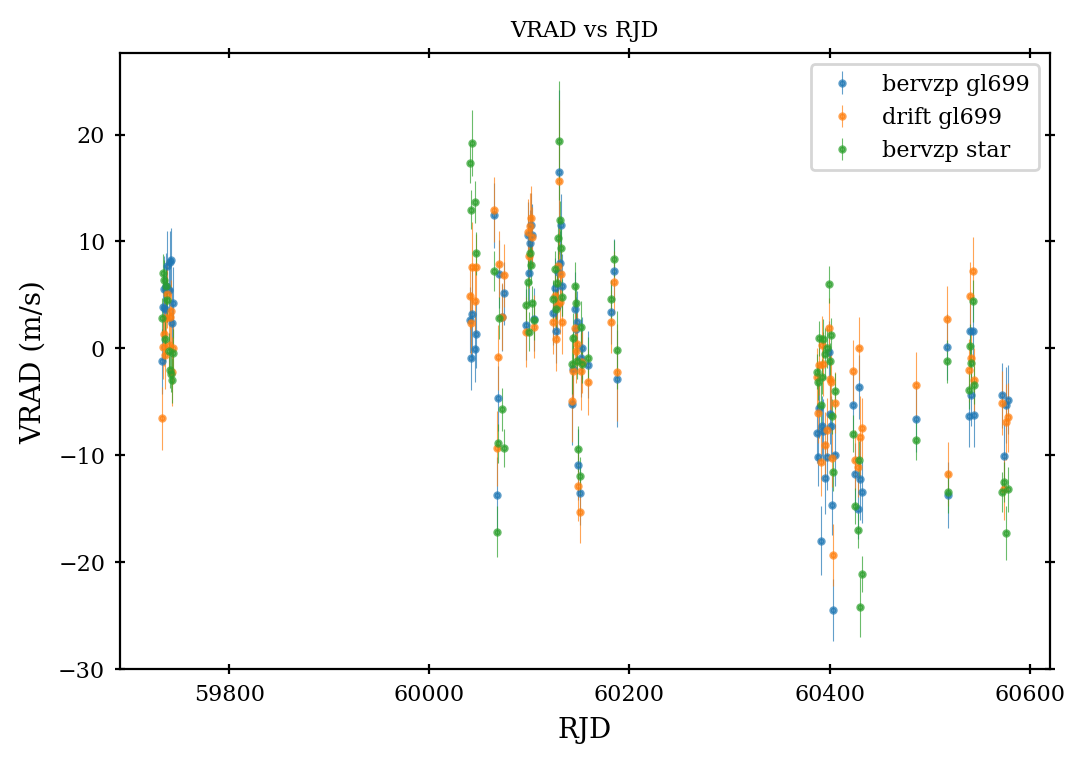

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(spirou_lbl2.rjd, spirou_lbl2.vrad - np.median(spirou_lbl2.vrad), yerr=spirou_lbl2.svrad, 
            fmt='o', label='bervzp gl699', markersize=2, elinewidth=0.4, alpha=0.7)
ax.errorbar(spirou_lbl2_drift.rjd, spirou_lbl2_drift.vrad - np.median(spirou_lbl2_drift.vrad), yerr=spirou_lbl2_drift.svrad, 
            fmt='o', label='drift gl699', markersize=2, elinewidth=0.4, alpha=0.7)
# ax.errorbar(spirou_lbl2_old.rjd, spirou_lbl2_old.vrad - np.median(spirou_lbl2_old.vrad), yerr=spirou_lbl2_old.svrad, 
#             fmt='o', label='old dataset gl699', markersize=2, elinewidth=0.4, alpha=0.7)
ax.errorbar(spirou_lbl2_star.rjd, spirou_lbl2_star.vrad - np.median(spirou_lbl2_star.vrad), yerr=spirou_lbl2_star.svrad, 
            fmt='o', label='bervzp star', markersize=2, elinewidth=0.4, alpha=0.7)

ax.set_xlabel('RJD')
ax.set_ylabel('VRAD (m/s)')
ax.set_title('VRAD vs RJD')
ax.legend()
plt.savefig('./plots/toi4438/spirou_lbl2_old_vs_new.png', dpi=200, bbox_inches='tight')
plt.show()

In [46]:
def filter_df(df, method="iqr", sigmas=3):
    l = len(df)
    df = df[df['EXTSN035'] > 60]
    df = df[df['svrad'] < 5]
    if method == "iqr":
        quarts = np.percentile(df['vrad'], [25, 75])
        iqr = stats.iqr(df['vrad'])
        lower = quarts[0] - 1.5 * iqr
        upper = quarts[1] + 1.5 * iqr
    elif method == "sigma":
        mean = np.mean(df['vrad'])
        std = np.std(df['vrad'])
        lower = mean - sigmas * std
        upper = mean + sigmas * std
    else:
        raise ValueError("method must be 'iqr' or 'sigma'")
    df = df[(df['vrad'] > lower) & (df['vrad'] < upper)]
    l2 = len(df)
    print(f"Filtered {l-l2} points")
    return df

def center_df(df):
    df['vrad'] = df['vrad'] - np.median(df['vrad'])
    return df
# first filter all the datasets for outliers using 3-sigma clipping in svrad and iqr in vrad
spirou_lbl2 = filter_df(spirou_lbl2)
spirou_lbl2_drift = filter_df(spirou_lbl2_drift)
spirou_lbl2_star = filter_df(spirou_lbl2_star)
spirou_lbl2_star_drift = filter_df(spirou_lbl2_star_drift)
spirou_lbl2_old = filter_df(spirou_lbl2_old)

spirou_lbl2 = center_df(spirou_lbl2)
spirou_lbl2_drift = center_df(spirou_lbl2_drift)
spirou_lbl2_star = center_df(spirou_lbl2_star)
spirou_lbl2_star_drift = center_df(spirou_lbl2_star_drift)
spirou_lbl2_old = center_df(spirou_lbl2_old)

Filtered 3 points
Filtered 3 points
Filtered 4 points
Filtered 4 points
Filtered 4 points


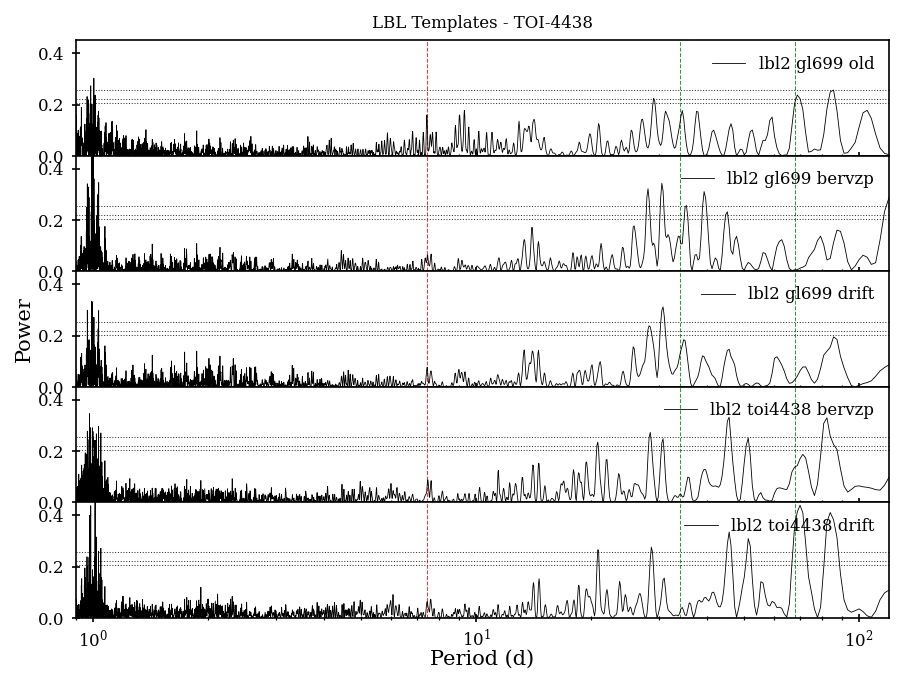

In [47]:
# check if the signal is present in any of the datasets
series = ['lbl2 gl699 old', 'lbl2 gl699 bervzp', 'lbl2 gl699 drift', 'lbl2 toi4438 bervzp', 
          'lbl2 toi4438 drift']

lg = [ls(spirou_lbl2_old.rjd, spirou_lbl2_old.vrad, spirou_lbl2_old.svrad),
      ls(spirou_lbl2.rjd, spirou_lbl2.vrad, spirou_lbl2.svrad),
      ls(spirou_lbl2_drift.rjd, spirou_lbl2_drift.vrad, spirou_lbl2_drift.svrad),
      ls(spirou_lbl2_star.rjd, spirou_lbl2_star.vrad, spirou_lbl2_star.svrad),
      ls(spirou_lbl2_star_drift.rjd, spirou_lbl2_star_drift.vrad, spirou_lbl2_star_drift.svrad),]

min_freq = 0.001
max_freq = 10
sppk = 5
probabilities = [0.1, 0.05, 0.01]

freq = {}
power = {}
fap = {}

for n, name in enumerate(series):
    freq[name], power[name] = lg[n].autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=sppk)
    fap[name] = lg[n].false_alarm_level(probabilities)

# plot the periodograms
fig, ax = plt.subplots(len(series), 1, sharex=True, sharey=True, figsize=(7,len(series)), dpi=150)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0)

for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color='r', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=68, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=68/2, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=0.4, label=name)
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 0.45)
    ax[i].set_xlim(0.9, 120)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right')
    ax[i].set_yticks([0.0, 0.2, 0.4])
    ax[i].tick_params(which='both', top=False, right=False)
    ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
    
bigax = fig.add_subplot(111, frameon=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2)
bigax.set_ylabel("Power", labelpad=2)
bigax.set_title(f'LBL Templates - {star_name}')
plt.savefig(f'./plots/toi4438/periodograms-by-reduction-template_{star_name}_new.png', dpi=200, facecolor='w', bbox_inches='tight')

In [26]:
np.corrcoef(spirou_lbl2['DTEMP3500'], spirou_lbl2['d2v'])

array([[1.        , 0.96865217],
       [0.96865217, 1.        ]])

In [27]:
# data to use:
spirou = spirou_lbl2.copy()

In [28]:
# d2v is "differential line width", an activity indicator. 
# d3v is then the column linked to the third derivative, it is supposed to be linked to the asymmetry of the line, 
# but as far as I know no one tries to use that product yet
spirou.head()

,rjd,vrad,svrad,d2v,sd2v,d3v,sd3v,DTEMP3000,sDTEMP3000,DTEMP3500,...,svrad_2080nm,vrad_2167nm,svrad_2167nm,vrad_2257nm,svrad_2257nm,vrad_2351nm,svrad_2351nm,vrad_2449nm,svrad_2449nm,VTOT
0,59732.984348,-1.278092,3.011778,9.922926e+05,14127.727704,3.214241e+07,2.537787e+07,144.647114,1.018338,170.892136,...,7.876829,-35154.668134,13.049668,-35273.196729,19.868333,-35102.603373,17.110817,-35074.166466,23.814433,-40.159553
1,59734.020205,3.791575,3.055206,1.001267e+06,14450.142224,2.218519e+07,2.599324e+07,146.346940,1.046711,171.089564,...,7.738416,-35135.201044,12.227306,-35188.319866,20.069309,-35090.193865,18.341151,-35080.799276,28.600846,-39.814070
2,59735.057384,5.462139,3.073093,9.614128e+05,14479.689154,1.399630e+07,2.609263e+07,142.054566,1.049241,165.951720,...,7.818620,-35101.589923,12.696802,-35178.359209,20.514134,-35091.160435,18.427836,-35072.355779,29.308974,-39.474188
3,59735.989705,3.574242,3.259028,1.062749e+06,15359.019695,1.863188e+07,2.770765e+07,150.242623,1.111156,176.644607,...,8.067943,-35100.423944,12.734536,-35175.989659,22.901982,-35108.372140,22.360143,-35057.262779,38.750358,-39.386168
4,59736.952200,5.766252,3.048833,1.014372e+06,14366.211934,1.886335e+07,2.587511e+07,146.343627,1.045115,170.810641,...,7.545585,-35122.827306,12.185450,-35196.357325,19.453141,-35130.441078,17.616078,-35065.831739,26.707788,-39.222113


In [29]:
carmenes.head()

,rjd,vrad,svrad
0,59720.6490,1.90,3.99
1,59726.5607,-6.93,2.02
2,59730.5751,-1.11,2.20
3,59736.5664,2.74,1.81
4,59738.6403,-3.77,1.97


### Plot RVs

Mean Uncertainties:
Spirou: 3.0841964532651893 m/s
Carmenes: 2.4993749999999997 m/s


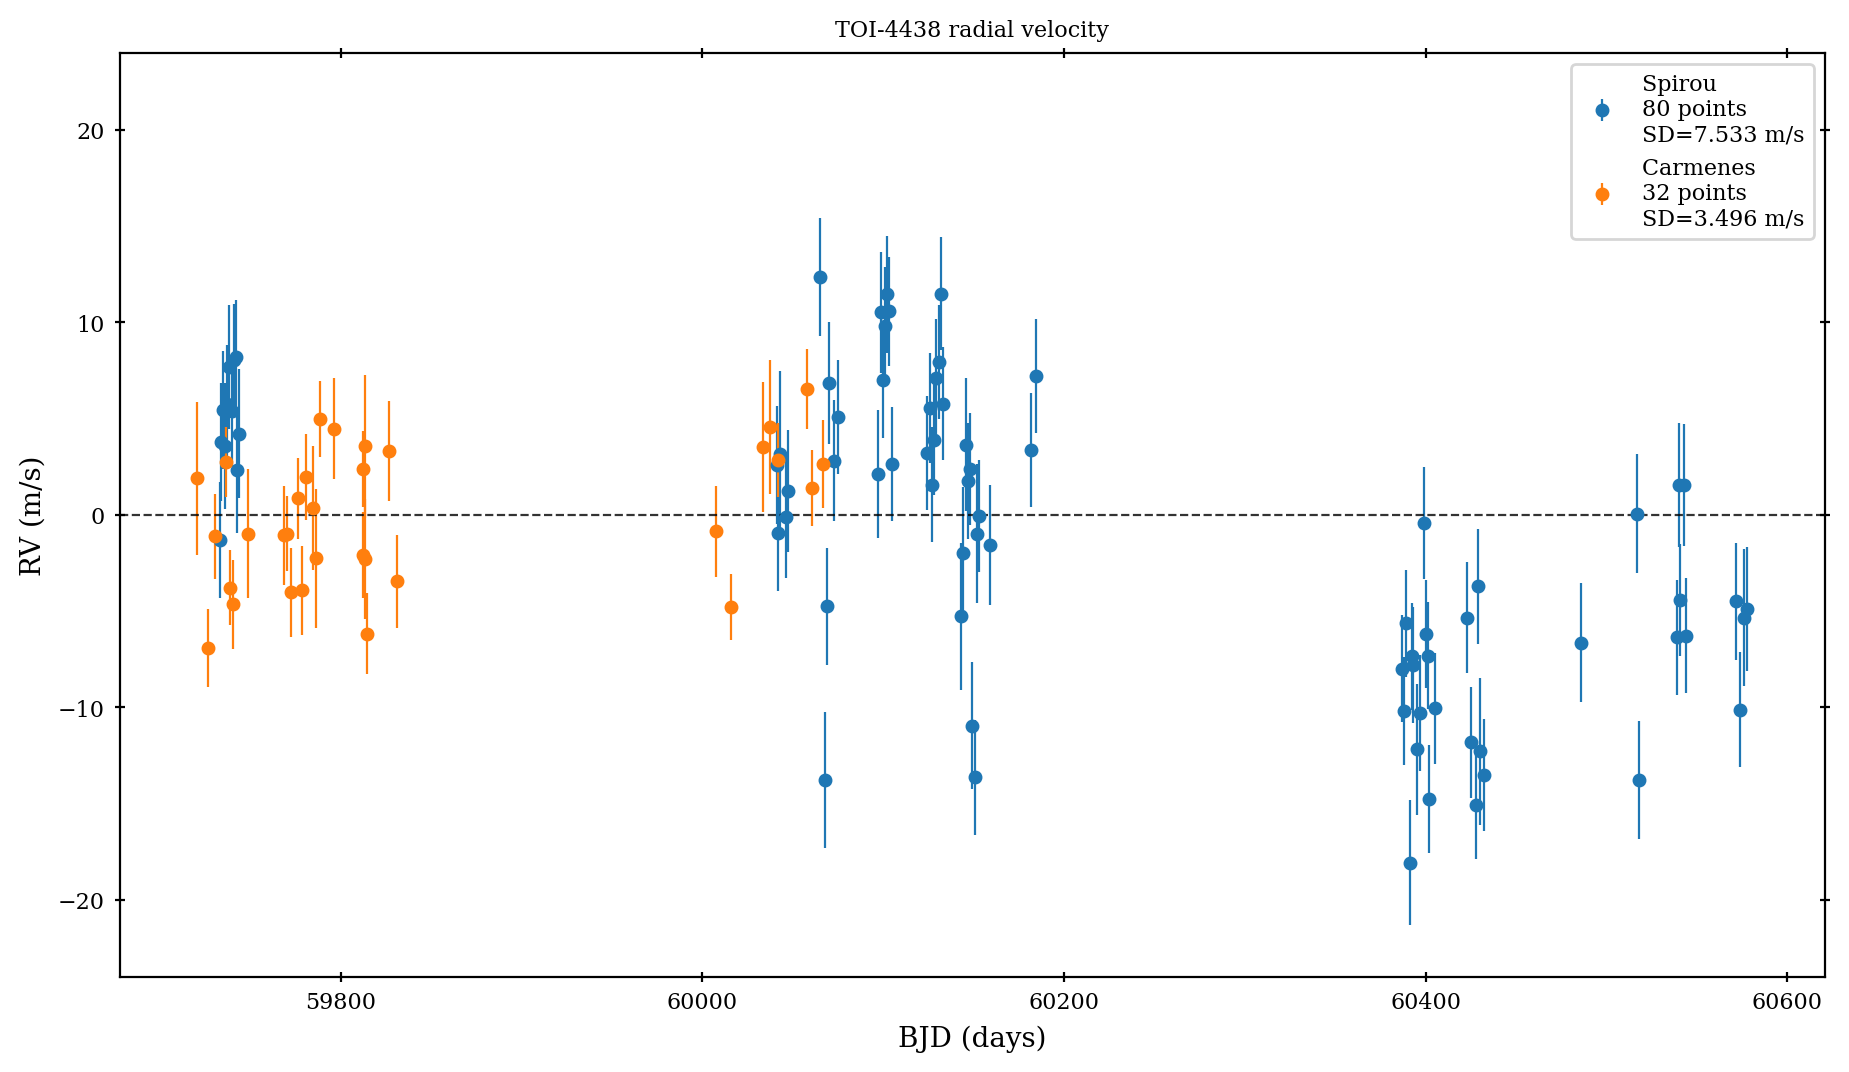

In [30]:
fig, ax = plt.subplots(figsize=(11, 6))
print('Mean Uncertainties:')
print('Spirou:', spirou['svrad'].mean(), 'm/s')
print('Carmenes:', carmenes['svrad'].mean(), 'm/s')
ax.errorbar(spirou['rjd'], spirou['vrad'], yerr=spirou['svrad'], fmt='o', label=f'Spirou \n{len(spirou)} points\nSD={np.round(np.std(spirou.vrad),3)} m/s', markersize=4, elinewidth=0.8, color='C0')
ax.errorbar(carmenes['rjd'], carmenes['vrad'], yerr=carmenes['svrad'], fmt='o', label=f'Carmenes \n{len(carmenes)} points\nSD={np.round(np.std(carmenes.vrad),3)} m/s', markersize=4, elinewidth=0.8, color='C1')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.8)
ax.legend()
ax.set_ylim(-24, 24)
ax.set_xlabel('BJD (days)')
ax.set_ylabel('RV (m/s)')
ax.set_title(f'{star_name} radial velocity')
plt.savefig(f'./plots/toi4438/all_rvs_{star_name}.png', dpi=200, facecolor='w', bbox_inches='tight')
plt.show()

In [31]:
# This is for the latex table in the paper
for i in range(len(spirou)):
    print(f"{spirou.reset_index()['rjd'][i]:.2f} & {spirou.reset_index()['vrad'][i]:.2f} & {spirou.reset_index()['svrad'][i]:.2f} & {spirou.reset_index()['d2v'][i]:.2f} & {spirou.reset_index()['sd2v'][i]:.2f} \\\\")

59732.98 & -1.28 & 3.01 & 992292.62 & 14127.73 \\
59734.02 & 3.79 & 3.06 & 1001267.28 & 14450.14 \\
59735.06 & 5.46 & 3.07 & 961412.76 & 14479.69 \\
59735.99 & 3.57 & 3.26 & 1062748.74 & 15359.02 \\
59736.95 & 5.77 & 3.05 & 1014371.65 & 14366.21 \\
59737.99 & 7.68 & 3.22 & 1063355.25 & 15108.63 \\
59739.99 & 5.38 & 2.90 & 1014893.61 & 13704.65 \\
59740.99 & 8.02 & 2.93 & 1024736.40 & 13823.12 \\
59741.98 & 8.22 & 2.95 & 1032518.58 & 13945.86 \\
59742.86 & 2.32 & 3.26 & 1052739.59 & 15256.86 \\
59743.89 & 4.22 & 3.35 & 1110776.95 & 15726.64 \\
60041.10 & 2.61 & 3.07 & 946000.37 & 14351.78 \\
60042.06 & -0.95 & 2.99 & 957420.18 & 13944.44 \\
60043.05 & 3.15 & 4.34 & 964210.14 & 17453.57 \\
60046.01 & -0.11 & 3.14 & 1040561.30 & 14862.63 \\
60047.13 & 1.24 & 3.16 & 975420.38 & 14746.90 \\
60065.02 & 12.38 & 3.06 & 1056969.33 & 14402.78 \\
60068.07 & -13.79 & 3.53 & 1063364.13 & 16728.40 \\
60068.96 & -4.74 & 3.04 & 1016971.61 & 14274.21 \\
60070.01 & 6.85 & 3.18 & 1059854.00 & 15220.22 \\

### Define RV variables

In [ ]:
# prepare the data for the model
nir_instruments = [spirou] 
opt_instruments = [carmenes]
xrv = np.concatenate((spirou['rjd'], carmenes['rjd']))
yrv = np.concatenate((spirou['vrad'], carmenes['vrad']))
yerrrv = np.concatenate((spirou['svrad'], carmenes['svrad']))
rv_inst_id = np.concatenate((np.zeros(len(spirou)), np.ones(len(carmenes))))
rv_band_id = np.concatenate((np.concatenate([np.zeros(len(i)) for i in nir_instruments]),
                             np.concatenate([np.ones(len(i)) for i in opt_instruments]))) 
rv_inst_error = []
for i, inst in enumerate(rv_inst_names):
    rv_inst_error.append(np.median(yerrrv[rv_inst_id == i]))
inds = np.argsort(xrv)
xrv = np.ascontiguousarray(xrv[inds], dtype=np.float64) - 57000.0
yrv = np.ascontiguousarray(yrv[inds], dtype=np.float64)
yerrrv = np.ascontiguousarray(yerrrv[inds], dtype=np.float64)
rv_inst_id = np.ascontiguousarray(rv_inst_id[inds], dtype=int)
rv_band_id = np.ascontiguousarray(rv_band_id[inds], dtype=int) # 0 will be nir, 1 optical

num_rv_inst = len(rv_inst_names)

### GLS analysis

In [ ]:
# series = ['spirou rvs', 'spirou dlw',  'carmenes rvs', 'all rvs', 'window function']
series = ['all rvs', 'spirou rvs', 'spirou dlw', 'spirou dTemp']

# lg = [ls(spirou.rjd, spirou.vrad, spirou.svrad),
#       ls(spirou.rjd, spirou.d2v, spirou.sd2v),
#       ls(carmenes.rjd, carmenes.vrad, carmenes.svrad),
#       ls(xrv, yrv, yerrrv),
#       ls(spirou.rjd, np.ones(len(spirou.rjd)), fit_mean=False, center_data=False)]
lg = [ls(xrv, yrv, yerrrv),
      ls(spirou.rjd, spirou.vrad, spirou.svrad),
      ls(spirou.rjd, spirou.d2v, spirou.sd2v),
      ls(spirou.rjd, spirou['DTEMP3500'], spirou['sDTEMP3500'])]

min_freq = 0.001
max_freq = 10
sppk = 5
probabilities = [0.1, 0.05, 0.01]

freq = {}
power = {}
fap = {}

for n, name in enumerate(series):
    freq[name], power[name] = lg[n].autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=sppk)
    if name != 'window function':
        fap[name] = lg[n].false_alarm_level(probabilities)

In [ ]:
# plot the periodograms
fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(7,4), dpi=150)
#fig.subplots_adjust(hspace=0, wspace=0)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0)

for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color='r', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=68, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=2*68, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=0.7, label=name)
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 0.75)
    ax[i].set_xlim(0.3, 1000)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right')
    ax[i].set_yticks([0.0, 0.3, 0.6])
    ax[i].tick_params(which='both', top=False, right=False)
    if name == "window function":
        ax[i].set_ylim(0, 1.2)
        ax[i].set_yticks([0.0, 0.5, 1.0])
    else:
        ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
        ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
        ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
    
bigax = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2)
bigax.set_ylabel("Power", labelpad=2)
bigax.set_title(f'GLS periodograms - {star_name}')
plt.savefig(f'./plots/toi4438/rv_periodograms_{star_name}_old.png', dpi=200, facecolor='w', bbox_inches='tight')

In [ ]:
# plot the periodograms
fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(7,4), dpi=150)
#fig.subplots_adjust(hspace=0, wspace=0)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0)

for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color='r', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=68, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=2*68, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=0.7, label=name)
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 0.75)
    ax[i].set_xlim(0.3, 1000)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right')
    ax[i].set_yticks([0.0, 0.3, 0.6])
    ax[i].tick_params(which='both', top=False, right=False)
    if name == "window function":
        ax[i].set_ylim(0, 1.2)
        ax[i].set_yticks([0.0, 0.5, 1.0])
    else:
        ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
        ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
        ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
    
bigax = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2)
bigax.set_ylabel("Power", labelpad=2)
bigax.set_title(f'GLS periodograms - {star_name}')
plt.savefig(f'./plots/toi4438/rv_periodograms_{star_name}.png', dpi=200, facecolor='w', bbox_inches='tight')

In [ ]:
def compute_one_day_aliases(P):
    f = 1 / P
    f_minus = abs(f - 1)
    f_plus = abs(f + 1)
    P_minus = 1 / f_minus
    P_plus = 1 / f_plus
    return P_minus, P_plus

def compute_aliases(P, n_list=[1, 2]):
    f = 1 / P
    aliases = []
    for n in n_list:
        for sign in [+1, -1]:
            f_alias = abs(f + sign * n)
            P_alias = 1 / f_alias
            aliases.append((n, sign, P_alias))
    return aliases

In [ ]:
compute_aliases(period_tess.nominal_value, n_list=[1, 2])

In [ ]:
fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(5,2.5), dpi=150)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
names_ = ['RVs', 'SPIRou RV', 'SPIRou dLW', 'SPIRou dTEMP']
for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color='r', linestyle='-', linewidth=0.5, alpha=0.3)
    ax[i].axvline(x=68.0, color='y', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=68.0/2, color='y', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=0.3, label=names_[i])
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 0.4)
    ax[i].set_xlim(1, 105)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right', fontsize=6, edgecolor='k', fancybox=False)
    ax[i].set_yticks([0.0, 0.2], labels=['0.0', '0.2'], size=8)
    ax[i].set_xticks([1, 10, 100], labels=['1', '10', '100'], size=8)
    ax[i].tick_params(which='both', top=False, right=False, direction='out', length=1.5)
    ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[2]*100}%', zorder=0)
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(0.5)
bigax = fig.add_subplot(111, frameon=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2, size=8)
bigax.set_ylabel("Power", labelpad=2, size=8)
plt.savefig(f'./plots/toi4438/rvgls_4438.png', dpi=400, facecolor='w', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=100)
ax.axvline(x=period_tess.nominal_value, color='r', linestyle='--', linewidth=0.5, alpha=0.8)
ax.axvline(x=68, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
ax.plot(1/freq[series[0]], power[series[0]], color='k', linewidth=0.7, label='RVs')
ax.set_xlim(1, 101)
ax.set_xscale('log')

## Read LCs

In [ ]:
#exofop: https://exofop.ipac.caltech.edu/tess/target.php?id=22233480

# tpf_search = lk.search_targetpixelfile('TIC 22233480')
# tpf_search

In [ ]:
# search = lk.search_lightcurve('TIC 22233480')
# search

In [ ]:
# read the saved lightcurves
read_file1 = pd.read_csv('./data/toi4438/lc_short_all.csv')
lc_short_all = lk.LightCurve(time=read_file1['time'], flux=read_file1['flux'], flux_err=read_file1['flux_err'])
read_file2 = pd.read_csv('./data/toi4438/lc_79_80_fast.csv')
lc_79_80_fast = lk.LightCurve(time=read_file2['time'], flux=read_file2['flux'], flux_err=read_file2['flux_err'])

In [ ]:
# plot sector 79 fast cadence
lc_79_80_fast.scatter()

### LC to use

In [ ]:
# for the model, short and fast cadence binned to short are concatenated 
time = np.asarray(lc_short_all.time.value)
flux = np.asarray(lc_short_all.flux.value)
flux_err = np.asarray(lc_short_all.flux_err.value)

# all sectors with 120s cadence
inds2 = np.argsort(time)
time = np.ascontiguousarray(time[inds2], dtype=np.float64)
flux = np.ascontiguousarray(flux[inds2], dtype=np.float64)
flux_err = np.ascontiguousarray(flux_err[inds2], dtype=np.float64)

# all sectors binned to 5 minutes for faster computation, 79 from 20s
# bin to 5 minutes and save to disk

#lc_short_5min = lc_short_all.bin(time_bin_size=5*u.min.to(u.day)).remove_nans()
#lc_short_5min.to_csv('./data/toi4438/lc_short_all_5min.csv')

# read the saved 5-min binned lightcurve
read_file3 = pd.read_csv('./data/toi4438/lc_short_all_5min.csv')
lc_short_5min = lk.LightCurve(time=read_file3['time'], flux=read_file3['flux'], flux_err=read_file3['flux_err'])

time5 = np.asarray(lc_short_5min.time.value)
flux5 = np.asarray(lc_short_5min.flux.value)
flux_err5 = np.asarray(lc_short_5min.flux_err.value)

# all sectors with 300s cadence
inds5 = np.argsort(time5)
time_5min = np.ascontiguousarray(time5[inds5], dtype=np.float64)
flux_5min = np.ascontiguousarray(flux5[inds5], dtype=np.float64)
flux_err_5min = np.ascontiguousarray(flux_err5[inds5], dtype=np.float64)

# get the exptimes
texp_2 = 2.0 / 60.0 / 24.0
texp_5 = 5.0 / 60.0 / 24.0

ref_time = np.min(time)

In [ ]:
# we're gonna split the lightcurves in 3 parts, sector 40, sector 52-53, and sector 79-80
# lets creat another variable to store the sector of each point, then the sector ID will be 0, 1, 2. 
# same as we did with different instruments in RVs
# sector 40 -> time < 2600
# sector 52-53 -> 2600 < time < 3000
# sector 79-80 -> time > 3000

# 2min cadence
sector_id = np.zeros(len(time), dtype=int)
sector_id[time > 2600] = 1
sector_id[time > 3000] = 2

# 5min cadence
sector_id_5min = np.zeros(len(time_5min), dtype=int)
sector_id_5min[time_5min > 2600] = 1
sector_id_5min[time_5min > 3000] = 2

sector_id_names = ['Sector_40', 'Sector_52_53', 'Sector_79_80']

### TLS analysis

In [ ]:
from transitleastsquares import transit_mask

In [ ]:
# load results from the TLS
with open('./results/tls/tls_complete_4438.pkl', 'rb') as f:
    results = pickle.load(f)

In [ ]:
print(results['period'], results['T0'], results['duration'], results['depth'], results['SDE'])
tls_p = results['period']
tls_t0 = results['T0']
tls_duration = results['duration']
tls_depth = results['depth']

### Transit masks

In [ ]:
intransit_5min = transit_mask(time_5min, tls_p, 1, tls_t0) # 1 day around the transits for faster modeling
intransit = transit_mask(time, tls_p, 1, tls_t0)
# just the transits 5min
intransit_5min_small = transit_mask(time_5min, tls_p, tls_duration*12, tls_t0) # only the transits
intransit_small = transit_mask(time, tls_p, tls_duration*12, tls_t0)
# just the transits 120s
in_transit = transit_mask(time, tls_p, tls_duration*12, tls_t0)

# plt.scatter(time_5min[intransit_5min], flux_5min[intransit_5min], s=1, color='red')  # in-transit points in red
# plt.scatter(time_5min[~intransit_5min], flux_5min[~intransit_5min], s=1, color='blue')  # other points in blue
plt.scatter(time_5min[intransit_5min_small], flux_5min[intransit_5min_small], s=1, color='red')  # in-transit points in red
plt.scatter(time_5min[~intransit_5min_small], flux_5min[~intransit_5min_small], s=1, color='blue')  # other points in blue
#plt.xlim(2410, 2412)
#plt.xlim(3482, 3484)

In [ ]:
# results phase folded
plt.figure()
plt.plot(results['model_folded_phase'], results['model_folded_model'], color='red', zorder=10)
plt.scatter(results['folded_phase'], results['folded_y'], color='blue', s=10, alpha=0.5)
plt.xlim(0.48, 0.52)
plt.xlabel('Phase')
plt.ylabel('Relative flux');

In [ ]:
tls_duration*10

In [ ]:
duration_tess/24

In [ ]:
# complete light curve with no transits
plt.figure()
plt.scatter(time[in_transit], flux[in_transit], color='red', s=2, zorder=0)
plt.scatter(time[~in_transit], flux[~in_transit], color='blue', alpha=0.5, s=2, zorder=0)
plt.plot(results['model_lightcurve_time'], results['model_lightcurve_model'], alpha=0.5, color='k', zorder=1)
plt.xlim(time.min(), time.max())
plt.xlabel('Time (days)')
plt.ylabel('Relative flux');
plt.xlim(2418,2420)

In [ ]:
ref_time + 594.6

## Modelo Global

### Model variables

In [ ]:
# load detrended lc's
read_detrended5 = pd.read_csv('./data/toi4438/detrended_lc_5min.csv')
lc_detrended5 = lk.LightCurve(time=read_detrended5['time'], flux=read_detrended5['flux'], flux_err=read_detrended5['flux_err'])

read_detrended = pd.read_csv('./data/toi4438/detrended_lc_2min.csv')
lc_detrended = lk.LightCurve(time=read_detrended['time'], flux=read_detrended['flux'], flux_err=read_detrended['flux_err'])

def get_xy(time_exp, version='short'):
    # parametros
    # ----------
    # time_exp: '120', '300' (int)
    # devuelve
    # ----------
    # x, y, yerr, texp (en días y ppt)
    if version == 'all':
        if time_exp == 120:
            t_ = time
            flux_ = flux
            flux_err_ = flux_err
            texp_ = texp_2
            id_ = sector_id
        elif time_exp == 300:
            t_ = time_5min
            flux_ = flux_5min
            flux_err_ = flux_err_5min
            texp_ = texp_5
            id_ = sector_id_5min
    elif version == '1day':
        if time_exp == 120:
            t_ = time[intransit]
            flux_ = flux[intransit]
            flux_err_ = flux_err[intransit]
            texp_ = texp_2
            id_ = sector_id[intransit]
        elif time_exp == 300:
            t_ = time_5min[intransit_5min]
            flux_ = flux_5min[intransit_5min]
            flux_err_ = flux_err_5min[intransit_5min]
            texp_ = texp_5
            id_ = sector_id_5min[intransit_5min]
    elif version == 'no-transits':
        if time_exp == 120:
            t_ = time[~intransit_small]
            flux_ = flux[~intransit_small]
            flux_err_ = flux_err[~intransit_small]
            texp_ = texp_2
            id_ = sector_id[~intransit_small]
        elif time_exp == 300:
            t_ = time_5min[~intransit_5min_small]
            flux_ = flux_5min[~intransit_5min_small]
            flux_err_ = flux_err_5min[~intransit_5min_small]
            texp_ = texp_5
            id_ = sector_id_5min[~intransit_5min_small]
    elif version == 'detrended-all':
        if time_exp == 300:
            t_ = lc_detrended5.time.value
            flux_ = lc_detrended5.flux.value
            flux_err_ = lc_detrended5.flux_err.value
            texp_ = texp_5
            id_ = sector_id_5min
            return t_, flux_, flux_err_, texp_, id_
        elif time_exp == 120:
            t_ = lc_detrended.time.value
            flux_ = lc_detrended.flux.value
            flux_err_ = lc_detrended.flux_err.value
            texp_ = texp_2
            id_ = sector_id
            return t_, flux_, flux_err_, texp_, id_
    elif version == 'detrended-1day':
        if time_exp == 300:
            t_ = lc_detrended5.time.value[intransit_5min]
            flux_ = lc_detrended5.flux.value[intransit_5min]
            flux_err_ = lc_detrended5.flux_err.value[intransit_5min]
            texp_ = texp_5
            id_ = sector_id_5min[intransit_5min]
            return t_, flux_, flux_err_, texp_, id_
        elif time_exp == 120:
            t_ = lc_detrended.time.value[intransit]
            flux_ = lc_detrended.flux.value[intransit]
            flux_err_ = lc_detrended.flux_err.value[intransit]
            texp_ = texp_2
            id_ = sector_id[intransit]
            return t_, flux_, flux_err_, texp_, id_

    x_ = np.ascontiguousarray(t_ - ref_time, dtype=np.float64)
    y_ = np.ascontiguousarray(1e3 * (flux_ - 1.0), dtype=np.float64) # Here we convert flux to ppt
    yerr_ = np.ascontiguousarray(1e3 * flux_err_, dtype=np.float64) 
    return x_, y_, yerr_, texp_, id_

def get_xy_rv():
    # just substract the reference time
    x_ = xrv - ref_time
    y_ = yrv
    yerr_ = yerrrv
    rv_inst_id_ = rv_inst_id
    return x_, y_, yerr_, rv_inst_id_

### Model version

In [ ]:
# lc para modelo
x, y, yerr, texp, id = get_xy(120, 'detrended-1day')

# rvs para modelo
x_rv, y_rv, yerr_rv, rv_inst_id = get_xy_rv()

In [ ]:
K_est = xo.estimate_semi_amplitude(tls_p, x_rv, y_rv, yerr_rv, t0s=tls_t0-ref_time)
print(K_est, "m/s")

In [ ]:
# versiones
# 0: per instrument offset en RVs
# 1: per instrument offset + quadratic drift en RVs
# 2: noise GP in RVs
# 3: noise GP in RVs + drift
# 4: QP-GP in RVs
# 5: QP-GP in RVs + drift

version_names = ['offset', 'drift', 'SHO-GP', 'SHO-GP+drift', 'QP-GP', 'QP-GP+drift']

version = 5

### Model build

In [ ]:
# time vectors for plotting
phase_lc = np.linspace(-0.3, 0.3, 500)
t_rv = np.linspace(x_rv.min() - 5, x_rv.max() + 5, 5000)
# Compute a reference time that will be used to normalize the trends model
x_ref = 0.5 * (x_rv.min() + x_rv.max())

def build_model(version=0, map=True):
    with pm.Model() as model:
        # Limb darkening pero sin initvals (exoplanets los usa por default [0.0,0.5])
        # because pymc error "cannot convert models with non-default initial_values" when using compute_likelihood() on posterior
        q1 = pm.Uniform("q1", lower=0.0, upper=1.0)
        q2 = pm.Uniform("q2", lower=0.0, upper=1.0)
        sqrtq1 = pt.sqrt(q1)
        twoq2 = 2 * q2
        u_star = pm.Deterministic("u_star", pt.stack([sqrtq1 * twoq2, sqrtq1 * (1 - twoq2)], axis=0))
        star = xo.LimbDarkLightCurve(u_star)
        
        # Stellar parameters from our determination
        mstar = pm.TruncatedNormal("mstar", mu=par.iloc[1].M, sigma=par.iloc[1].M_err, lower=0.0, upper=1.0)
        rstar = pm.TruncatedNormal("rstar", mu=par.iloc[1].R, sigma=par.iloc[1].R_err, lower=0.0, upper=1.0)

        # Orbital parameters for the planet
        # t0 = pm.Normal("t0", mu=tls_t0-ref_time, sigma=3*tls_duration)
        log_t0 = pm.Normal("log_t0", mu=np.log(tls_t0-ref_time), sigma=0.1)
        t0 = pm.Deterministic("t0", pt.exp(log_t0))

        # P = pm.LogNormal("P", mu=np.log(tls_p), sigma=results['period_uncertainty']/tls_p)
        log_P = pm.Normal("log_P", mu=np.log(tls_p), sigma=results['period_uncertainty']/tls_p)
        P = pm.Deterministic("P", pt.exp(log_P))

        # K = pm.Uniform("K", lower=0, upper=15.0)
        log_K = pm.Normal("log_K", mu=np.log(K_est), sigma=0.1)
        K = pm.Deterministic("K", pt.exp(log_K))

        # Fit in terms of ror
        # ror = pm.LogNormal("ror", mu=0.5*np.log((1-np.nanmean(results['transit_depths']))), sigma=np.nanmean(results['transit_depths_uncertainties'])/(1-np.nanmean(results['transit_depths'])))
        log_ror = pm.Normal("log_ror", mu=0.5*np.log((1-np.nanmean(results['transit_depths']))), sigma=np.nanmean(results['transit_depths_uncertainties'])/(1-np.nanmean(results['transit_depths'])))
        ror = pm.Deterministic("ror", pt.exp(log_ror))
        r_pl = pm.Deterministic("r_pl", ror * rstar)
        b = pm.Uniform("b", lower=0.0, upper=1.0) 
    
        ecc = pm.Uniform("e", lower=0.0, upper=0.5)
        omega = pm.Uniform("w", lower=-np.pi, upper=np.pi)
        
        # e1, e2 = xo.unit_disk("e1", "e2", initval=np.array([0.01, 0.01]))
        # ecc = pm.Deterministic("e", e1**2 + e2**2)
        # omega = pm.Deterministic("w", pt.arctan2(e2, e1))    

        # derived parameters
        m_pl = pm.Deterministic('m_pl', K*pt.sqrt(1-ecc**2)*(P*u.day.to(u.second)*(mstar*u.M_sun.to(u.kg))**2/(2*np.pi*constants.G))**(1/3)*u.kg.to(u.M_earth))
        density_pl = pm.Deterministic('density_pl', m_pl*u.M_earth.to(u.g)/(4/3*np.pi*(r_pl*u.R_sun.to(u.cm))**3))    
        a = pm.Deterministic('a', ((P*u.day.to(u.second))**2*constants.G*(mstar*u.M_sun.to(u.kg)+m_pl*u.M_earth.to(u.kg))/(4*np.pi**2))**(1/3)*u.m.to(u.au))
        teq = pm.Deterministic('teq', par.iloc[1].teff*(rstar*u.R_sun.to(u.au)/a)**(1/2)*(1/4)**(1/4))
    
        # Orbit model
        orbit = xo.orbits.KeplerianOrbit(
                r_star=rstar,
                m_star=mstar,
                period=P,
                t0=t0,
                b=b,
                ecc=ecc,
                omega=omega,
                )

        # Function to compute he light curve model
        def lc_model(mean_, star, r_pl, texp_, t_):
            return pt.sum(1e3*star.get_light_curve(orbit=orbit, r=r_pl, t=t_, texp=texp_), axis=-1) + mean_

        lc_mean = pm.Normal("lc_mean", mu=0.0, sigma=1.0) # mean flux
        logs = pm.Normal("logs", mu=np.log(np.std(y)), sigma=1) # tess jitter
        err_lc = pt.sqrt(yerr**2 + pt.exp(2 * logs)) # jitter + error

        # compute the model light curve
        lc_mod = lc_model(lc_mean, star, r_pl, texp, x)
        lc_phase_mod = lc_model(lc_mean, star, r_pl, texp, t0 + phase_lc)

        # the likelihood for the light curves
        pm.Normal("lc_obs", mu=lc_mod, sigma=err_lc, observed=y) 
        pm.Deterministic("lc", lc_mod)
        pm.Deterministic("lc_phase", lc_phase_mod)
    
        # rv model versions
        if version == 0:
            # Function for computing the full RV model
            def get_rv_model(x, name=""):
                vrad = orbit.get_radial_velocity(x, K=K)
                pm.Deterministic("vrad" + name, vrad)
                return pm.Deterministic("rv_model" + name, vrad)

            # Per instrument parameters
            means = pm.Normal("means", mu=0, sigma=3.0, shape=num_rv_inst)
            # sigmas = pm.HalfNormal("sigmas", sigma=10.0, shape=num_rv_inst)
            log_sigmas = pm.Normal("log_sigmas", mu=np.log(np.array(rv_inst_error)), sigma=1, shape=num_rv_inst)

            mean = pt.zeros(len(x_rv))
            sigma = pt.zeros(len(x_rv))
            for i in range(len(rv_inst_names)):
                mean += means[i] * (rv_inst_id == i)
                # sigma += (yerr_rv**2 + sigmas[i]**2) * (rv_inst_id == i)
                sigma += (yerr_rv**2 + pt.exp(2 * log_sigmas[i])) * (rv_inst_id == i)

            pm.Deterministic("mean", mean)
            pm.Deterministic("sigma", sigma)

            # rv model
            rv_mod = get_rv_model(x_rv) + mean
            get_rv_model(t_rv, "_pred")

            # the likelihood for the rvs
            err = pt.sqrt(sigma)
            pm.Normal("obs", mu=rv_mod, sigma=err, observed=y_rv)

        elif version == 1:      
            # RV quadratic trend, remove the constant term because we're using a per instrument mean
            trend = pm.Normal("trend", mu=0, sigma=np.array([0.01, 0.1 , 1.]), shape=3)
            # Function for computing the full RV model
            def get_rv_model(x, name=""):
                vrad = orbit.get_radial_velocity(x, K=K)
                pm.Deterministic("vrad" + name, vrad)

                # Define the background model
                # Use only the first two columns (we removed the constant term)
                A = np.vander(x - x_ref, 3)
                bkg = pm.Deterministic("bkg" + name, pt.dot(A, trend))
                return pm.Deterministic("rv_model" + name, vrad + bkg)

            # Per instrument parameters
            means = pm.Normal("means", mu=0, sigma=3.0, shape=num_rv_inst)
            # sigmas = pm.HalfNormal("sigmas", sigma=10.0, shape=num_rv_inst)
            log_sigmas = pm.Normal("log_sigmas", mu=np.log(np.array(rv_inst_error)), sigma=1, shape=num_rv_inst)

            mean = pt.zeros(len(x_rv))
            sigma = pt.zeros(len(x_rv))
            for i in range(len(rv_inst_names)):
                mean += means[i] * (rv_inst_id == i)
                sigma += (yerr_rv**2 + pt.exp(2 * log_sigmas[i])) * (rv_inst_id == i)

            pm.Deterministic("mean", mean)
            pm.Deterministic("sigma", sigma)

            # rv model
            rv_mod = get_rv_model(x_rv) + mean
            get_rv_model(t_rv, "_pred")

            # the likelihood for the rvs
            err = pt.sqrt(sigma)
            pm.Normal("obs", mu=rv_mod, sigma=err, observed=y_rv)

        elif version == 2 or version == 4:
            # Function for computing the full RV model
            def get_rv_model(x, name=""):
                vrad = orbit.get_radial_velocity(x, K=K)
                pm.Deterministic("vrad" + name, vrad)
                return pm.Deterministic("rv_model" + name, vrad)
            
            # Per instrument parameters
            means = pm.Normal("means", mu=0, sigma=3.0, shape=num_rv_inst)
            log_sigmas = pm.Normal("log_sigmas", mu=np.log(np.array(rv_inst_error)), sigma=1, shape=num_rv_inst)
            
            # Compute the RV offset and jitter for each data point depending on its instrument
            mean = pt.zeros(len(x_rv))
            diag = pt.zeros(len(x_rv))

            for i in range(num_rv_inst):
                mean += means[i] * (rv_inst_id == i)
                diag += (yerr_rv**2 + pt.exp(2 * log_sigmas[i])) * (rv_inst_id == i)
            pm.Deterministic("mean", mean)
            pm.Deterministic("diag", diag)

            rv_mod = get_rv_model(x_rv) + mean
            get_rv_model(t_rv, "_pred")

            if version == 2:
                # Noise model parameters
                # sigma_gp_rv = pm.Uniform("sigma_gp_rv", lower=0.0, upper=20)
                # rho_gp_rv = pm.Uniform("rho_gp_rv", lower=0.0, upper=1000.0)
                sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv))
                log_rho_gp = pm.Normal("log_rho_gp", mu=np.log(68), sigma=2.0)
                kernelrv = terms.SHOTerm(
                    sigma=sigma_gp, 
                    rho=pt.exp(log_rho_gp), 
                    Q=1.0 / 3)

            elif version == 4:
                # QP-GP model parameters
                # sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv))
                # Q0 = pm.Uniform("Q0", lower=3.14, upper=1000.0)
                # dQ = pm.Uniform("dQ", lower=0.001, upper=1000.0)
                # f = pm.Uniform("f", lower=0.0, upper=1.0)
                sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv))
                gp_period = pm.Uniform("gp_period", lower=50.0, upper=100.0)
                log_Q0 = pm.Uniform("log_Q0", lower=1, upper=8)
                log_dQ = pm.Uniform("log_dQ", lower=-3, upper=10)
                f = pm.Uniform("f", lower=0.1, upper=1.0)
                kernelrv = terms.RotationTerm(
                    sigma=sigma_gp,
                    period=gp_period,
                    Q0=pt.exp(log_Q0),
                    dQ=pt.exp(log_dQ),
                    f=f)

            # this is the marginal implementation of the GP, the problem with it is that we cannot compute LOO
            gp_rv = GaussianProcess(kernelrv, t=x_rv, mean=rv_mod, diag=diag)
            gp_rv.marginal("obs", observed=y_rv)
            # predictions for marginal implementation
            pm.Deterministic("gp_rv_pred", gp_rv.predict(y_rv, include_mean=False))
            #pm.Deterministic("gp_rv_pred_plot", gp_rv.predict(y_rv, t_rv, include_mean=False))

            # # this is the latent implementation
            # pm.Normal("y_obs", mu=rv_mod + f_gp, sigma=pt.sqrt(diag), observed=y_rv)
            # # predictions for latent implementation
            # pm.Deterministic("gp_rv_pred", f_gp)

        elif version == 3 or version == 5:
            # RV quadratic trend, remove the constant term because we're using a per instrument mean
            trend = pm.Normal("trend", mu=0, sigma=np.array([0.01, 0.1, 1.]), shape=3)

            # Function for computing the full RV model
            def get_rv_model(x, name=""):
                vrad = orbit.get_radial_velocity(x, K=K)
                pm.Deterministic("vrad" + name, vrad)
                # Define the background model
                # Use only the first two columns (we removed the constant term)
                A = np.vander(x - x_ref, 3)
                bkg = pm.Deterministic("bkg" + name, pt.dot(A, trend))
                return pm.Deterministic("rv_model" + name, vrad + bkg)

                        
            # Per instrument parameters
            means = pm.Normal("means", mu=0, sigma=3.0, shape=num_rv_inst)
            log_sigmas = pm.Normal("log_sigmas", mu=np.log(np.array(rv_inst_error)), sigma=1, shape=num_rv_inst)
            
            # Compute the RV offset and jitter for each data point depending on its instrument
            mean = pt.zeros(len(x_rv))
            diag = pt.zeros(len(x_rv))

            for i in range(num_rv_inst):
                mean += means[i] * (rv_inst_id == i)
                diag += (yerr_rv**2 + pt.exp(2 * log_sigmas[i])) * (rv_inst_id == i)
            pm.Deterministic("mean", mean)
            pm.Deterministic("diag", diag)


            rv_mod = get_rv_model(x_rv) + mean
            get_rv_model(t_rv, "_pred")
            
            if version == 3:
                # Noise model parameters
                sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv), shape=2) # nIR and optical
                log_rho_gp = pm.Normal("log_rho_gp", mu=np.log(68), sigma=2.0)
                kernelrv = terms.SHOTerm(
                    sigma=sigma_gp, 
                    rho=pt.exp(log_rho_gp), 
                    Q=1.0 / 3)
                
            elif version == 5:
                # sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv))
                sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv), shape=2) # nIR and optical
                gp_period = pm.Uniform("gp_period", lower=50.0, upper=100.0)
                log_Q0 = pm.Uniform("log_Q0", lower=1, upper=8)
                log_dQ = pm.Uniform("log_dQ", lower=-3, upper=10)
                Q0= pm.Deterministic("Q0", pt.exp(log_Q0))
                dQ= pm.Deterministic("dQ", pt.exp(log_dQ))
                f = pm.Uniform("f", lower=0.1, upper=1.0)
                
                kernelrv_nir = terms.RotationTerm(
                    sigma=sigma_gp[0],
                    period=gp_period,
                    Q0=Q0,
                    dQ=dQ,
                    f=f)
                
                kernelrv_opt = terms.RotationTerm(
                    sigma=sigma_gp[1],
                    period=gp_period,
                    Q0=Q0,
                    dQ=dQ,
                    f=f)
                
            # gp_rv = GaussianProcess(kernelrv, t=x_rv, mean=rv_mod, diag=diag)
            gp_rv_nir = GaussianProcess(kernelrv_nir, t=x_rv[(rv_band_id == 0)], mean=rv_mod[(rv_band_id == 0)], diag=diag[(rv_band_id == 0)])
            gp_rv_opt = GaussianProcess(kernelrv_opt, t=x_rv[(rv_band_id == 1)], mean=rv_mod[(rv_band_id == 1)], diag=diag[(rv_band_id == 1)])

            # gp_rv.marginal("obs", observed=y_rv)
            gp_rv_nir.marginal("obs_nir", observed=y_rv[(rv_band_id == 0)])
            gp_rv_opt.marginal("obs_opt", observed=y_rv[(rv_band_id == 1)])
            # predictions for marginal implementation
            # pm.Deterministic("gp_rv_pred", gp_rv.predict(y_rv, include_mean=False))
            pm.Deterministic("gp_rv_pred_nir", gp_rv_nir.predict(y_rv[(rv_band_id == 0)], include_mean=False))
            pm.Deterministic("gp_rv_pred_opt", gp_rv_opt.predict(y_rv[(rv_band_id == 1)], include_mean=False))
            #pm.Deterministic("gp_rv_pred_plot", gp_rv.predict(y_rv, t_rv, include_mean=False))
            
        else:
            raise ValueError('Version not found')
        
        if map:
            # Find MAP
            if version in [1, 3, 5]:
                map_soln = pm.find_MAP(vars=[trend])
                map_soln = pm.find_MAP(start=map_soln, vars=[log_sigmas])
            else:
                map_soln = pm.find_MAP(vars=[log_sigmas])
            map_soln = pm.find_MAP(start=map_soln, vars=[means])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_t0])
            map_soln = pm.find_MAP(start=map_soln, vars=[logs])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_P])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_K])
            map_soln = pm.find_MAP(start=map_soln, vars=[b])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_ror])
            if version in [2, 3]:
                map_soln = pm.find_MAP(start=map_soln, vars=[log_rho_gp])
                map_soln = pm.find_MAP(start=map_soln, vars=[sigma_gp])
            elif version in [4, 5]:
                map_soln = pm.find_MAP(start=map_soln, vars=[sigma_gp])
                map_soln = pm.find_MAP(start=map_soln, vars=[gp_period])
                map_soln = pm.find_MAP(start=map_soln, vars=[log_Q0])
                map_soln = pm.find_MAP(start=map_soln, vars=[log_dQ])
                map_soln = pm.find_MAP(start=map_soln, vars=[f])
            # map_soln = pm.find_MAP(start=map_soln, vars=[e1, e2_])
            map_soln = pm.find_MAP(start=map_soln, vars=[ecc])
            map_soln = pm.find_MAP(start=map_soln, vars=[omega])
            map_soln = pm.find_MAP(start=map_soln, vars=[q1, q2])
            map_soln = pm.find_MAP(start=map_soln, vars=[mstar, rstar])
            map_soln = pm.find_MAP(start=map_soln)
        else:
            map_soln = None
    return model, map_soln

model, map_soln = build_model(version=version, map=True)

#### MAP plots

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, dpi=150)

# ax = axes[0]
# lc_mod = map_soln["lc"] # lc + mean
# ax.plot(x, y, ".k")
# ax.plot(x, lc_mod, label="lc model")
# ax.text(x=0.03, y=0.9, s=f'RMS: {np.std(y):.2f} ppt', transform=ax.transAxes)
# ax.legend(fontsize=10)
# ax.set_ylabel("relative flux [ppt]")
# ax.set_title('LC map model', fontsize=14)

# # residuals of lc model
# ax = axes[1]
# ax.plot(x, y - lc_mod, ".k")
# ax.text(x=0.03, y=0.9, s=f'RMS: {np.std(y - lc_mod):.2f} ppt', transform=ax.transAxes)
# ax.axhline(0, color="#aaaaaa", lw=1)
# ax.set_ylabel("residuals [ppt]")
# ax.set_xlim(x.min(), x.max())
# ax.set_xlabel("time [days]")
# plt.xlim(345, 360)
# # plt.xlim(1050, 1120)
# # plt.xlim(1062, 1064)

# #plt.savefig(f'./plots/toi4438/map_lc_{version_names[version]}.png', dpi=200, bbox_inches='tight', pad_inches=0.1)
# plt.show()

In [ ]:
# fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharey=True)
# fig.subplots_adjust(hspace=0.3)

# for i, name in enumerate(rv_inst_names):
#     m = rv_inst_id == i
#     if version == 2 or version == 3 or version == 4 or version == 5:
#         ax[0].errorbar(x_rv[m], y_rv[m] - map_soln["mean"][m] - map_soln["gp_rv_pred"][m], yerr=yerr_rv[m], fmt=".", 
#                    elinewidth=1, markersize=3, label=name, zorder=-1000)
#     else:
#         ax[0].errorbar(x_rv[m], y_rv[m] - map_soln["mean"][m], yerr=yerr_rv[m], fmt=".", 
#                    elinewidth=1, markersize=3, label=name, zorder=-1000)
    
# ax[0].plot(t_rv, map_soln["rv_model_pred"], lw=0.5, color="k", label="model")
# ax[0].set_ylabel("RV [m/s]")
# ax[0].set_xlabel("time [days]")
# ax[0].legend(fontsize=8, loc='upper right', frameon=True)
# ax[0].set_title('RV map model', fontsize=14)
# #ax[0].set_xlim(700,750)
# folded = (x_rv - map_soln["t0"] + 0.5 * map_soln["P"]) % map_soln["P"] - 0.5 * map_soln["P"]
# inds = np.argsort(folded)
# for i, name in enumerate(rv_inst_names):
#     m = rv_inst_id == i
#     xfold = (x_rv[m] - map_soln["t0"] + 0.5 * map_soln["P"]) % map_soln["P"] - 0.5 * map_soln["P"]
#     inds = np.argsort(xfold)
#     if version == 0:
#         ax[1].errorbar(xfold[inds]/map_soln["P"], y_rv[m][inds] - map_soln["mean"][m], yerr=yerr_rv[m][inds], fmt=".",
#                     elinewidth=1, markersize=3, label=name, zorder=-1000)
#     elif version == 1:
#         ax[1].errorbar(xfold[inds]/map_soln["P"], y_rv[m][inds] - map_soln["mean"][m] - map_soln["bkg"][m][inds], yerr=yerr_rv[m][inds], fmt=".",
#                     elinewidth=1, markersize=3, label=name, zorder=-1000)
#     elif version == 2 or version == 4:
#         ax[1].errorbar(xfold[inds]/map_soln["P"], y_rv[m][inds] - map_soln["mean"][m] - map_soln["gp_rv_pred"][m][inds], yerr=yerr_rv[m][inds], fmt=".",
#                     elinewidth=1, markersize=3, label=name, zorder=-1000)
#     elif version == 3 or version == 5:
#         ax[1].errorbar(xfold[inds]/map_soln["P"], y_rv[m][inds] - map_soln["mean"][m] - map_soln["bkg"][m][inds] - map_soln["gp_rv_pred"][m][inds], 
#                        yerr=yerr_rv[m][inds], fmt=".", elinewidth=1, markersize=3, label=name, zorder=-1000)
# folded_t = (t_rv - map_soln["t0"] + 0.5 * map_soln["P"]) % map_soln["P"] - 0.5 * map_soln["P"]
# inds2 = np.argsort(folded_t)

# ax[1].plot(folded_t[inds2]/map_soln["P"], map_soln["vrad_pred"][inds2], "k", lw=0.5)
# ax[1].plot(folded_t[inds2]/map_soln["P"], map_soln["vrad_pred"][inds2], "k", lw=0.5)

# ax[1].set_ylabel("RV [m/s]")
# ax[1].set_xlabel("Phase")
# #plt.savefig(f'./plots/toi4438/map_rv_{version_names[version]}.png', dpi=200, bbox_inches='tight', pad_inches=0.1)

### Posterior Sampling

In [ ]:
with model:
    trace = pm.sample(
        draws=3000,
        tune=3000,
        initvals=map_soln,
        chains=2,
        target_accept=0.95, 
        init="adapt_full",
    )

In [ ]:
pm.compute_log_likelihood(trace, model=model)

In [ ]:
# # trace to save
az.to_netcdf(trace, f'./saves/toi4438/trace.global{star_name}_v{version}_{version_names[version]}.save')

# save to trace
# trace = az.from_netcdf(f'./saves/toi4438/trace.global{star_name}_v{version}_{version_names[version]}.save')

# only version 5 has the gp predictions for plotting

In [ ]:
if version == 0:
    var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means"]
elif version == 1:
    var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","trend","log_sigmas","means"]
elif version == 2:
    var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means","sigma_gp","log_rho_gp"]
elif version == 3:
    var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","trend","log_sigmas","means","sigma_gp","log_rho_gp"]
elif version == 4:
    var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means","sigma_gp","log_Q0","log_dQ","f","gp_period"]
elif version == 5:
    var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","trend","log_sigmas","means","sigma_gp","log_Q0","log_dQ","f","gp_period"]
summary = az.summary(trace, kind='all', hdi_prob=0.68, 
                     round_to=6, stat_focus='median', var_names=var_names)
summary

In [ ]:
# trace plot
fig, ax = plt.subplots(len(var_names), 2, figsize=(10,30), dpi=150)
fig.subplots_adjust(hspace=0.5)
az.plot_trace(trace, var_names=var_names, axes=ax)
# plt.savefig(f'./plots/toi4438/trace_{version_names[version]}.png', dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

### Resulting parameters

In [ ]:
flat_samps = trace.posterior.stack(sample=("chain", "draw"))

In [ ]:
import pickle
from uncertainties.umath import *
from asymmetric_uncertainty import a_u

params = {}
with open(f'./results/toi4438/{star_name}_v{version}_{version_names[version]}.txt', 'w') as f:
    for var in flat_samps.data_vars:
        if flat_samps[var].ndim > 1 and flat_samps[var].shape[0] > 3:
            continue
        else:
            if flat_samps[var].ndim > 1:
                for n in range(flat_samps[var].shape[0]):
                    parameter = a_u(flat_samps[var].median(dim='sample').values[n],
                                flat_samps[var].quantile(q=0.84, dim='sample').values[n]-flat_samps[var].median(dim='sample').values[n],
                                flat_samps[var].median(dim='sample').values[n]-flat_samps[var].quantile(q=0.16, dim='sample').values[n])
                    print(var+f'_{n}', " = {r:.6f}".format(r=parameter))
                    params[var+f'_{n}'] = parameter
                    f.write(var+f'_{n} = {parameter:.6f}\n')
            else:
                if var == 'r_pl':
                    parameter = a_u(flat_samps[var].median().item()*u.R_sun.to(u.R_earth),
                                flat_samps[var].quantile(q=0.84).item()*u.R_sun.to(u.R_earth)-flat_samps[var].median().item()*u.R_sun.to(u.R_earth),
                                flat_samps[var].median().item()*u.R_sun.to(u.R_earth)-flat_samps[var].quantile(q=0.16).item()*u.R_sun.to(u.R_earth))
                else:
                    parameter = a_u(flat_samps[var].median().item(),
                                    flat_samps[var].quantile(q=0.84).item()-flat_samps[var].median().item(),
                                    flat_samps[var].median().item()-flat_samps[var].quantile(q=0.16).item())
                print(var, " = {r:.6f}".format(r=parameter))
                params[var] = parameter
                f.write(f'{var} = {parameter:.6f}\n')
    print('----------------')
    tess_jitter = np.exp(params['logs'])
    print('tess_jitter = {:.3f}'.format(tess_jitter))
    params['tess_jitter'] = tess_jitter
    f.write(f'tess_jitter = {tess_jitter:.3f}\n')
    print('----------------')
    num = flat_samps['b'].values * (1.0 + flat_samps['e'].values * np.sin(flat_samps['w'].values))
    den = (flat_samps['a'].values*u.au.to(u.R_sun) /  flat_samps['rstar'].values) * (1.0 - flat_samps['e'].values**2)
    cosi = num / den
    inclination = np.degrees(np.arccos(cosi))
    inclination_u = a_u(np.median(inclination), np.percentile(inclination, 84) - np.median(inclination), np.median(inclination)- np.percentile(inclination, 16))
    print(f'inclination = {inclination_u:.6f} deg')
    f.write(f'inclination = {inclination_u:.6f}\n')
    print('----------------')
    num = np.sqrt((1+flat_samps['ror'].values)**2 - flat_samps['b'].values**2)
    den = (flat_samps['a'].values*u.au.to(u.R_sun) /  flat_samps['rstar'].values) * np.sin(np.radians(inclination)) 
    arg = num / den
    Tdur = (flat_samps['P'].values / np.pi) * np.arcsin(arg) * u.day.to(u.hour)
    Tdur_u = a_u(np.median(Tdur), np.percentile(Tdur, 84) - np.median(Tdur), np.median(Tdur)- np.percentile(Tdur, 16))
    print(f'Tdur = {Tdur_u:.6f} hours')
    f.write(f'Tdur = {Tdur_u:.6f}\n')
    print('----------------')
    for i, inst in enumerate(rv_inst_names):
        jitter = np.exp(params['log_sigmas_'+str(i)])
        params[f'{inst}_jitter'] = jitter
        print(f'{inst}_jitter = {jitter:.3f}')
        f.write(f'{inst}_jitter = {jitter:.3f}\n')
    print('----------------')
    # Precisions:
    key_params = ['m_pl_0', 'r_pl', 'P', 't0']
    for param in key_params:
        precision = np.max(params[param].items()[1:])/params[param].items()[0]*100
        params[param+'_precision'] = precision
        print(f'{param} precision: {precision:.4f} %')
        f.write(f'{param}_precision = {precision:.4f} %\n')
# save to pickle
with open(f'./results/toi4438/{star_name}_v{version}_{version_names[version]}.pkl', 'wb') as f1:
    pickle.dump(params, f1)
f.close()
f1.close()                            

In [ ]:
# improve period uncertainty?
# goffo et al: 7.44628 +/- 0.000009
params['P']

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(12,4))
for i in range(3):
    ax[i].hist(flat_samps['trend'][i].values)
    ax[i].axvline(az.hdi(flat_samps['trend'][i].values, hdi_prob=.95)[0], linestyle='--', color='k')
    ax[i].axvline(az.hdi(flat_samps['trend'][i].values, hdi_prob=.95)[1], linestyle='--', color='k')
    # annotate the values of hdi
    ax[i].text(0.05, 0.9, f'95% HDI:\n{az.hdi(flat_samps["trend"][i].values, hdi_prob=.95)[0]:.6f} to {az.hdi(flat_samps["trend"][i].values, hdi_prob=.97)[1]:.6f}',
               transform=ax[i].transAxes, bbox=dict(facecolor='white', alpha=0.8))
plt.savefig(f'./plots/toi4438/trend_hdi_v{version}.png', dpi=100, bbox_inches='tight', facecolor='w')

In [ ]:
for i in range(3):
    print(f'trend_{i} value: {params[f"trend_{i}"]:.6f}')
    print(f'trend_{i} sigmas: {params[f"trend_{i}"].value/((params[f"trend_{i}"].minus + params[f"trend_{i}"].plus)/2):.1f}')

In [ ]:
x_rv.max() - x_rv.min()

In [ ]:
# plot the drift from x_rv.min() to x_rv.max()
plt.plot(x_rv, np.median(flat_samps['bkg'], axis=-1))
# paint the 16th and 84th percentiles
plt.fill_between(x_rv, np.percentile(flat_samps['bkg'], 16, axis=-1), np.percentile(flat_samps['bkg'], 84, axis=-1), alpha=0.3)
plt.plot(t_rv, np.median(flat_samps['bkg_pred'], axis=-1))
plt.fill_between(t_rv, np.percentile(flat_samps['bkg_pred'], 16, axis=-1), np.percentile(flat_samps['bkg_pred'], 84, axis=-1), alpha=0.3)

In [ ]:
np.max(np.median(flat_samps['bkg_pred'], axis=-1))-np.min(np.median(flat_samps['bkg_pred'], axis=-1))

In [ ]:
deltav = flat_samps['bkg_pred'].values[np.argmax(np.median(flat_samps['bkg_pred'], axis=-1)),:]-flat_samps['bkg_pred'].values[np.argmin(np.median(flat_samps['bkg_pred'], axis=-1)),:]
print(f'Delta RV over time span: {np.median(deltav):.1f} +{(np.percentile(deltav, 84)-np.percentile(deltav, 16))/2:.1f} m/s')

### Cornerplot

In [ ]:
CORNER_KWARGS = dict(
    smooth=0.5,
    plot_density=True,
    plot_datapoints=True,
    fill_contours=False,
    #levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
    levels=(0.16,0.5,0.84),
    max_n_ticks=3
)

In [ ]:
from cProfile import label
import corner
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter()

fig, ax = plt.subplots(7, 7, figsize=(9, 9))

figure = corner.corner(trace, var_names=['P', 'K', 'r_pl', 'm_pl', 'b', 'e', 'w'],
                        labels=["P (d)", "K (m s$^{-1}$)", "R$_P$ (R$_S$)", "M$_P$ (M$_E$)", "b", "e", "$\omega~$(rad)"], label_kwargs={'fontsize':12},
                        show_titles=False, title_kwargs={'fontsize':12, 'pad':9.0}, titles=['P', 'K', 'R\_P','M\_P','b','e','$\omega$'], divergences=False, plot_contours=True,
                        labelpad=0.1, color='k', fig=fig, **CORNER_KWARGS)
for i,ax in enumerate(figure.get_axes()):
    ax.tick_params(axis='both', pad=1, direction='in', labelbottom=True, labelleft=True, left=True, bottom=True)
    
# plt.savefig(f'./plots/toi4438/corner1_{star_name}_v{version}_{version_names[version]}.png', dpi=100, bbox_inches='tight', facecolor='w')
plt.show()

In [ ]:
# paper figure

# CORNER_KWARGS_ = dict(
#     smooth=0.5,
#     plot_density=True,
#     plot_datapoints=True,
#     fill_contours=True,
#     #levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
#     levels=(0.16,0.5,0.84),
#     max_n_ticks=3, 
#     data_kwargs={'alpha': 0.9, 'ms': 0.5},)

# fig, ax = plt.subplots(12, 12, figsize=(9, 9))
# corner_vars = ["t0","P","K","ror","b","e","w","sigma_gp","gp_period", "log_Q0","log_dQ","f"]
# figure = corner.corner(trace, var_names=corner_vars,
#                         labels=["t0 (d)", "P (d)", "K (m s$^{-1}$)", "R$_P$/R$_\star$", "b", "e", "$\omega~$(rad)",
#                                 "$\sigma_{GP}$ (m s$^{-1}$)", "P$_{GP}$", "$\log$ Q$_0$", "$\log$ dQ", "$f$"], label_kwargs={'fontsize':8},
#                         show_titles=False, divergences=False, plot_contours=True, hist_kwargs={'linewidth': 0.5},
#                         labelpad=0.2, fig=fig, contour_kwargs={'linewidths': 0.5}, **CORNER_KWARGS_)
# for i,ax in enumerate(figure.get_axes()):
#     ax.tick_params(axis='both', pad=0.5, length=1, direction='in', labelsize=7, 
#                    labelbottom=True, labelleft=True, left=True, bottom=True)
#     for axis in ['top','bottom','left','right']:
#         ax.spines[axis].set_linewidth(0.5)
# plt.savefig(f'./plots/paper/corner_4438.png', dpi=400, bbox_inches='tight', facecolor='w')

In [ ]:
## Corner GP parameters
if version == 2 or version == 3:
    gp_vars = ['sigma_gp', 'log_rho_gp']
    figure = corner.corner(trace, var_names=gp_vars, label_kwargs={'fontsize':16})
    for i, ax in enumerate(figure.get_axes()):
        ax.tick_params(labelsize=14)
    plt.savefig(f'./plots/toi4438/corner2_{star_name}_v{version}_{version_names[version]}.png', dpi=100, bbox_inches='tight', facecolor='w')
elif version == 4 or version == 5: 
    gp_vars = ['gp_period', 'sigma_gp', 'log_Q0', 'log_dQ', 'f']
    figure = corner.corner(trace, var_names=gp_vars, label_kwargs={'fontsize':16})
    for i, ax in enumerate(figure.get_axes()):
        ax.tick_params(labelsize=14)
    plt.savefig(f'./plots/toi4438/corner2_{star_name}_v{version}_{version_names[version]}.png', dpi=100, bbox_inches='tight', facecolor='w')

### RV fit plots

In [ ]:
period = np.median(flat_samps["P"])
t0_ = np.median(flat_samps["t0"])
rv_model = np.percentile(flat_samps['rv_model'].values, [16,50,84], axis=-1)
rv_model_pred = np.percentile(flat_samps["rv_model_pred"].values, [16,50,84], axis=-1)
vrad_ = np.percentile(flat_samps["vrad"].values, [16,50,84], axis=-1)
vrad_pred_ = np.percentile(flat_samps["vrad_pred"].values, [16,50,84], axis=-1)
mean_ = flat_samps['mean'].median(axis=-1)
if version == 1 or version == 3 or version == 5:
    bkg_pred_ = flat_samps['bkg_pred'].median(axis=-1)
lc_model = np.percentile(flat_samps['lc'].values, [16,50,84], axis=-1)
lc_phase = np.percentile(flat_samps["lc_phase"], [16,50,84], axis=-1)

if version == 2 or version == 3 or version == 4 or version == 5:
    gp_rv_pred = np.percentile(flat_samps["gp_rv_pred"].values, [16,50,84], axis=-1)
    if version == 5:
        gp_rv_pred_plot = np.percentile(flat_samps["gp_rv_pred_plot"].values, [16,50,84], axis=-1)

means = dict()
residuals = np.zeros(len(y_rv))
background = np.zeros(len(y_rv))
gpandmean = np.zeros(len(y_rv))

for i, name in enumerate(rv_inst_names):
    m = rv_inst_id == i
    means[name] = a_u(np.median(flat_samps["mean"].values, axis=-1)[m].mean(), 
                     np.quantile(flat_samps["mean"].values, q=0.84, axis=-1)[m].mean(),
                     np.quantile(flat_samps["mean"].values, q=0.16, axis=-1)[m].mean())   
    if version == 0: 
        background[m] = background[m] + mean_[m]
    elif version == 1:
        background[m] = background[m] + np.median(flat_samps['bkg'].values, axis=-1)[m] + mean_[m]
    elif version == 2 or version == 4:
        background[m] = background[m] + gp_rv_pred[1][m] + mean_[m]
    elif version == 3 or version == 5:
        background[m] = background[m] + np.median(flat_samps['bkg'].values, axis=-1)[m] + gp_rv_pred[1][m] + mean_[m]
        gpandmean[m] = gpandmean[m] + gp_rv_pred[1][m] + mean_[m]
    residuals[m] = residuals[m] + (y_rv[m] - vrad_[1][m] - background[m])

In [ ]:
import matplotlib as mpl
cmap = mpl.colormaps['tab20']
cmap

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True, dpi=200)
fig.subplots_adjust(hspace=0)

ax[0].set_title(f"v{version} - {version_names[version]} - {star_name}", fontsize=14)
ax[0].set_xlim(x_rv.min()-20, x_rv.max()+20)
ax[2].set_xlabel("BTJD - ref_time (days)")
ax[0].set_ylabel("RV (m/s)")
ax[1].set_ylabel("Detrended (m/s)")
ax[2].set_ylabel("Residuals (m/s)")

labels_ = ['Keplerian', 'Keplerian + drift', 'Keplerian + SHO GP', 'Keplerian + SHO GP + drift', 
           'Keplerian + QP GP', 'Keplerian + QP GP + drift']
for i, name in enumerate(rv_inst_names):
    fmt = ['v', 'o'] # ['v', '^']
    colors = [cmap(2), cmap(4)]
    m = rv_inst_id == i
    # ax 0
    ax[0].errorbar(x_rv[m], y_rv[m] - mean_[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)
    if version == 0 or version == 1:
        ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=0.7, zorder=-100, alpha=0.5,  label=labels_[version])
        art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
                                color=cmap(0), alpha=0.15, zorder=2) 
        art.set_edgecolor("none")
        ax[0].legend()
    elif version == 2 or version == 3 or version == 4 or version == 5:
        # to better plot the GP model, but takes longer to sample..
        # ax[0].plot(t_rv, gp_rv_pred_plot[1], linestyle='--', color='k', lw=1.5, zorder=-50)
        # ax[0].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=cmap(0), lw=0.7, zorder=-100, alpha=0.5,  label=labels_[version])
        # art = ax[0].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + gp_rv_pred_plot[2], 
        #                         color=cmap(0), alpha=0.15, zorder=2) 
        # art.set_edgecolor("none")
        ax[0].legend()
        ax[0].plot(x_rv, gp_rv_pred[1], linestyle='--', color='k', lw=1.5, zorder=-50)
        ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=0.7, zorder=-100, alpha=0.5,  label=labels_[version])
        art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
                                color=cmap(0), alpha=0.15, zorder=2) 
        art.set_edgecolor("none")
        ax[0].legend()
    # ax 1
    ax[1].errorbar(x_rv[m], y_rv[m] - background[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)
    ax[1].plot(t_rv, vrad_pred_[1], color=cmap(16), lw=0.7, zorder=-100, alpha=0.5,  label='Keplerian')
    art = ax[1].fill_between(t_rv, vrad_pred_[0], vrad_pred_[2], 
                            color=cmap(16), alpha=0.15, zorder=2) 
    art.set_edgecolor("none")

    # ax 2
    ax[2].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
    ax[2].axhline(0, linestyle='--', color='k', lw=1, zorder=-100)
    if i == 0:
        ax[1].legend(fontsize=8, loc='upper left', ncols=2)
        ax[1].legend(fontsize=8, loc='upper left')
    ax[2].legend(fontsize=8, loc='upper left', ncols=2)

plt.savefig(f'./plots/toi4438/rv_paper_{star_name}_v{version}_{version_names[version]}.png', dpi=300, facecolor='w', bbox_inches='tight')
plt.show()

RV fit for paper

In [ ]:
cmap

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(10, 6), sharey=True, dpi=200)
fig.subplots_adjust(hspace=0.0, wspace=0.05)

y_labels = ['RV ($m s^{-1}$)', 'RV ($m s^{-1}$)', 'RV residuals ($m s^{-1}$)']
for i in range(3):
    ax[i,0].set_xlim(x_rv.min()-10, x_rv.min()+190)
    ax[i,1].set_xlim(610, 810)
    ax[i,2].set_xlim(990, 1190)
    ax[i,0].set_ylim(-12,12)
    ax[i,0].set_ylabel(y_labels[i], labelpad=0.1, size=7)
    ax[i,0].spines.right.set_visible(False)
    ax[i,1].spines.left.set_visible(False)
    ax[i,1].spines.right.set_visible(False)
    ax[i,2].spines.left.set_visible(False)
    ax[i,1].yaxis.set_ticks_position('none')
    ax[i,0].yaxis.set_ticks_position('left')
    ax[i,2].yaxis.set_ticks_position('right')
    ax[i,0].set_yticks([-10,-5,0,5,10])
    ax[i,0].set_yticklabels(['-10', '', '0', '', '10'])
    ax[i,0].set_xticks([325, 350, 375, 400, 425, 450, 475, 500])
    ax[i,0].set_xticklabels(['', '350', '', '400', '', '450', '', '500'])
    ax[i,1].set_xticks([625, 650, 675, 700, 725, 750, 775, 800])
    ax[i,1].set_xticklabels(['', '650', '', '700', '', '750', '', '800'])
    ax[i,2].set_xticks([1000, 1025, 1050, 1075, 1100, 1125, 1150, 1175])
    ax[i,2].set_xticklabels(['1000', '', '1050', '', '1100', '', '1150', ''])
    for j in range(3):
        ax[i,j].tick_params(direction='in', length=1.5, labelsize=7)
        for axis in ['top','bottom','left','right']:
            ax[i,j].spines[axis].set_linewidth(0.5)
ax[2,0].annotate('Time (BJD - 2,457,000.0)', xy=(0.44, 0.04), xycoords='figure fraction', ha='center', va='bottom', fontsize=7)
d = .5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=6,
              linestyle="none", color='k', mec='k', mew=0.5, clip_on=False)
ax[0,0].plot([1, 1], [0, 1], transform=ax[0,0].transAxes, **kwargs)
ax[0,1].plot([0, 0], [1, 0], transform=ax[0,1].transAxes, **kwargs)
ax[0,1].plot([1, 1], [0, 1], transform=ax[0,1].transAxes, **kwargs)
ax[0,2].plot([0, 0], [1, 0], transform=ax[0,2].transAxes, **kwargs)
ax[1,0].plot([1, 1], [0, 1], transform=ax[1,0].transAxes, **kwargs)
ax[1,1].plot([0, 0], [1, 0], transform=ax[1,1].transAxes, **kwargs)
ax[1,1].plot([1, 1], [0, 1], transform=ax[1,1].transAxes, **kwargs)
ax[1,2].plot([0, 0], [1, 0], transform=ax[1,2].transAxes, **kwargs)
ax[2,0].plot([1, 1], [0, 1], transform=ax[2,0].transAxes, **kwargs)
ax[2,1].plot([0, 0], [1, 0], transform=ax[2,1].transAxes, **kwargs)
ax[2,1].plot([1, 1], [0, 1], transform=ax[2,1].transAxes, **kwargs)
ax[2,2].plot([0, 0], [1, 0], transform=ax[2,2].transAxes, **kwargs)

plot_lw = 0.5
models_c = 'k'
msize = 3
elinew = 0.4 
inst_labels = ['SPIRou', 'CARMENES']
for i, name in enumerate(rv_inst_names):
    fmt = ['o', 'o'] # ['v', '^']
    colors = [cmap(1), cmap(3)]
    m = rv_inst_id == i
    
    # ax[0,0].errorbar(x_rv[m], y_rv[m] - gpandmean[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
    #             markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=inst_labels[i])
    # ax[0,0].plot(t_rv, rv_model_pred[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1,  label='Keplerian + Drift') # Old version: only planet rv model (gp subtracted)
    ax[0,0].errorbar(x_rv[m], y_rv[m] - mean_[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=inst_labels[i])

    ax[0,1].errorbar(x_rv[m], y_rv[m] - gpandmean[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)
    
    ax[0,2].errorbar(x_rv[m], y_rv[m] - gpandmean[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

    # ax 1
    ax[1,0].errorbar(x_rv[m], y_rv[m] - mean_[m] - rv_model[1][m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                   markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

    ax[1,1].errorbar(x_rv[m], y_rv[m] - mean_[m] - rv_model[1][m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                   markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

    ax[1,2].errorbar(x_rv[m], y_rv[m] - mean_[m] - rv_model[1][m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                   markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

    # ax 2
    ax[2,0].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
    ax[2,0].axhline(0, linestyle='--', color=models_c, lw=plot_lw, zorder=-100)

    ax[2,1].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
    ax[2,1].axhline(0, linestyle='--', color=models_c, lw=plot_lw, zorder=-100)

    ax[2,2].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
    ax[2,2].axhline(0, linestyle='--', color=models_c, lw=plot_lw, zorder=-100)

# Models
ax[0,0].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1,  label='Full model')
art = ax[0,0].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + gp_rv_pred_plot[2], color='k', alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[0,1].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1)
art = ax[0,1].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + gp_rv_pred_plot[2], color=models_c, alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[0,2].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1)
art = ax[0,2].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + gp_rv_pred_plot[2], color=models_c, alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[1,0].plot(t_rv, gp_rv_pred_plot[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1,  label='GP model')
art = ax[1,0].fill_between(t_rv, gp_rv_pred_plot[0], gp_rv_pred_plot[2], color=models_c, alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[1,1].plot(t_rv, gp_rv_pred_plot[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1)
art = ax[1,1].fill_between(t_rv, gp_rv_pred_plot[0], gp_rv_pred_plot[2], color=models_c, alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[1,2].plot(t_rv, gp_rv_pred_plot[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1)
art = ax[1,2].fill_between(t_rv, gp_rv_pred_plot[0], gp_rv_pred_plot[2], color=models_c, alpha=0.15, zorder=2) 
art.set_edgecolor("none")

handles, labels = ax[0,0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax[0,0].legend(unique_labels.values(), unique_labels.keys(),fontsize=5, loc='upper left', framealpha=0.0, ncol=3)

handles, labels = ax[1,0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax[1,0].legend(unique_labels.values(), unique_labels.keys(),fontsize=5, loc='upper left', framealpha=0.0)

# Title
ax[0,0].annotate('TOI-4438', xy=(0.44, 0.86), xycoords='figure fraction', ha='center', va='bottom', fontsize=8, fontweight='light') 
# plt.savefig(f'./plots/toi4438/rvfit_4438.png', dpi=300, facecolor='w', bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharey=True)
fig.subplots_adjust(hspace=0.0)

if version == 2 or version == 3 or version == 4 or version == 5:
    # # to better plot the GP model, but takes longer to sample..
    # ax[0].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=cmap(0), lw=1, zorder=-50)
    # art = ax[0].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + gp_rv_pred_plot[2], 
    #                          color=cmap(0), alpha=0.5, zorder=2) 
    ax[0].plot(x_rv, gp_rv_pred[1], linestyle='--', color='k', lw=1, zorder=-50)
    ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=1, zorder=-50)
    art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
                             color=cmap(0), alpha=0.5, zorder=2) 
elif version == 0 or version == 1: 
    ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=1, zorder=-50)
    art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
                             color="#FF7F00", alpha=0.5, zorder=2) 

art.set_edgecolor("none")
for i, name in enumerate(rv_inst_names):
    m = rv_inst_id == i
    ax[0].errorbar(x_rv[m], y_rv[m] - mean_[m], yerr=yerr_rv[m], fmt="o", color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1)
ax[0].legend(fontsize=10)
ax[0].set_xlim(x_rv.min()-10, x_rv.max()+10)
ax[0].set_xlabel("BTJD - ref_time (days)")
ax[0].set_ylabel("RV (m/s)")
ax[0].set_title(f"v{version} - {version_names[version]} - {star_name}", fontsize=14)

for i, name in enumerate(rv_inst_names):
    m = rv_inst_id == i
    fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
    inds = np.argsort(fold)
    ax[1].errorbar(fold[inds]/period, y_rv[m][inds] - background[m][inds], yerr=yerr_rv[m][inds], fmt="o", color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1)

fold2 = (t_rv - t0_ + 0.5 * period) % period - 0.5 * period
inds2 = np.argsort(fold2)
ax[1].plot(fold2[inds2]/period, vrad_pred_[1][inds2], color=cmap(0), lw=1, zorder=-50)
art = ax[1].fill_between(fold2[inds2]/period, vrad_pred_[0][inds2], vrad_pred_[2][inds2], color=cmap(0), alpha=0.5, zorder=2) 
art.set_edgecolor("none")
ax[1].set_xlim(-0.51, 0.51)
ax[1].set_xlabel("Phase")
ax[1].set_ylabel("Residuals (m/s)")
ax[0].text(.01, .99, 'K = {k:.4f} m/s'.format(k=params['K_0']), fontsize=11, ha='left', va='top', transform=ax[0].transAxes)
ax[0].text(.01, .92, 'Mp = {k:.4f} Mearth'.format(k=params['m_pl_0']), fontsize=11, ha='left', va='top', transform=ax[0].transAxes)
ax[1].text(.01, .99, 'RVs STD = {k:.4f} m/s'.format(k=np.std(y_rv)), fontsize=11, ha='left', va='top', transform=ax[1].transAxes)
ax[1].text(.01, .92, 'Resid STD = {k:.4f} m/s'.format(k=np.std(residuals)), fontsize=11, ha='left', va='top', transform=ax[1].transAxes)
plt.tight_layout()
plt.savefig(f'./plots/toi4438/rv_fit_{star_name}_v{version}_{version_names[version]}.png', dpi=300, facecolor='w', bbox_inches='tight')
plt.show()

Plot with residuals for paper

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(5, 3), dpi=150, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.0)

plot_lw = 0.5
models_c = 'k'
msize = 3
elinew = 0.4 
inst_labels = ['SPIRou', 'CARMENES']
fmt = ['o', 'o'] 
colors = [cmap(1), cmap(3)]
ax[0].set_ylabel('RV - GP ($m s^{-1}$)', labelpad=0.05, size=7)

for i, name in enumerate(rv_inst_names):
    m = rv_inst_id == i
    fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
    inds = np.argsort(fold)
    ax[0].errorbar(fold[inds]/period, y_rv[m][inds] - background[m][inds], yerr=yerr_rv[m][inds], fmt=fmt[i], color=colors[i], 
                   elinewidth=elinew, markersize=msize, label=inst_labels[i], markeredgewidth=0.3, markeredgecolor='k', alpha=0.9)

fold2 = (t_rv - t0_ + 0.5 * period) % period - 0.5 * period
inds2 = np.argsort(fold2)
ax[0].plot(fold2[inds2]/period, vrad_pred_[1][inds2], "k", lw=plot_lw, label='Keplerian')
art = ax[0].fill_between(fold2[inds2]/period, vrad_pred_[0][inds2], vrad_pred_[2][inds2], color='k', alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[0].set_xlim(-0.51, 0.51)
ax[0].set_ylim(-18,18)
for i in range(2):
    ax[i].tick_params(direction='in', length=1.5, labelsize=7)
    ax[i].set_yticks([-15,-10,-5,0,5,10,15])
    ax[i].set_yticklabels(['','-10', '', '0', '', '10',''])
    ax[i].set_xticks(np.arange(-0.45,0.46,0.05))
    ax[i].set_xticklabels(['','-0.4','','','','-0.20','','','','0.0','','','','0.20','','','','0.40',''])
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(0.5)
for i, name in enumerate(rv_inst_names):
    m = rv_inst_id == i
    fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
    inds = np.argsort(fold)
    ax[1].errorbar(fold[inds]/period, residuals[m][inds], yerr=yerr_rv[m][inds], fmt=fmt[i], color=colors[i], 
                   elinewidth=elinew, markersize=msize, label=inst_labels[i], markeredgewidth=0.3, markeredgecolor='k', alpha=0.9)
ax[1].axhline(y=0, ls='--', color='k', linewidth=1, alpha=0.5, zorder=1)
ax[1].set_ylabel('Residuals ($m s^{-1}$)', labelpad=0.05, size=7)
ax[1].set_xlabel("Phase", labelpad=0.4, size=7)
ax[0].legend(fontsize=5, loc='upper left', framealpha=0.0, ncol=3)
ax[0].text(0.85, 0.96, 'TOI-4438', fontsize=7, color='k', fontweight='semibold',
        ha='left', va='top', transform=ax[0].transAxes, 
        bbox=dict(boxstyle="square", alpha=0.0, ec=(0., 0., 0.), fc=(1., 1., 1.)))
# plt.savefig(f'./plots/toi4438/rv_fit_resid_{star_name}_v{version}_{version_names[version]}.png', dpi=300, facecolor='w', bbox_inches='tight')

# plt.savefig(f'./plots/toi4438/rvfit_phase_4438.png', dpi=300, facecolor='w', bbox_inches='tight')
plt.show()

### GLS of residuals

Periodogram of the residuals

In [ ]:
probabilities_ = [0.05, 0.01, 0.001]

In [ ]:
fig, ax = plt.subplots(len(rv_inst_names)+1, 1, figsize=(6, len(rv_inst_names)+1), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.0)
lg = ls(x_rv, residuals)
fr, pw = lg.autopower(minimum_frequency=1/300, maximum_frequency=max_freq, samples_per_peak=sppk)
fp = lg.false_alarm_level(probabilities)
ax[0].axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
ax[0].axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
ax[0].axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
ax[0].plot(1/fr, pw, color='k', linewidth=0.7, label='all rvs residuals')
ax[0].set_ylabel('power')
ax[0].set_xlim(0.3, 300)
ax[0].set_ylim(0,1)
ax[0].set_xscale('log')
ax[0].legend(fontsize=5)
ax[0].set_title(f'GLS of residuals - {star_name}')
ax[0].set_yticks([0, 0.4, 0.8])
for i, name in enumerate(rv_inst_names):
    m = rv_inst_id == i
    lg = ls(x_rv[m], residuals[m])
    fr, pw = lg.autopower(minimum_frequency=1/300, maximum_frequency=max_freq)
    fp = lg.false_alarm_level(probabilities)
    ax[i+1].plot(1/fr, pw, color='k', linewidth=0.7, label=name+' residuals')
    ax[i+1].axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i+1].axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i+1].axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
    ax[i+1].set_ylabel('power')
    ax[i+1].legend(fontsize=5)
ax[i+1].set_xlabel('Period (days)')
plt.savefig(f'./plots/toi4438/rv_residuals_gls_v{version}_{version_names[version]}.png', dpi=200, facecolor='w', bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=200)

lg_all = ls(x_rv, residuals)
fr_all, pw_all = lg_all.autopower(minimum_frequency=1/300, maximum_frequency=max_freq, samples_per_peak=sppk)
fp = lg_all.false_alarm_level(probabilities)
ax.axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
ax.axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
ax.axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
ax.plot(1/fr_all, pw_all, color='k', linewidth=0.3, label='all rvs residuals')
ax.set_ylabel('power')
ax.set_xlim(1, 300)
ax.set_xscale('log')
ax.set_ylim(0,0.3)
ax.legend(fontsize=5)
plt.savefig(f'./plots/toi4438/rv_ALL_residuals_gls_v{version}_{version_names[version]}.png', dpi=200, facecolor='w', bbox_inches='tight')

In [ ]:
# plt.plot(spirou.rjd, spirou['DTEMP3500'], 'o')
plt.scatter(spirou['DTEMP3500'], spirou.d2v)

In [ ]:
series = ['all rvs', 'spirou rvs', 'spirou dlw', 'spirou dtemp', 'keplerian residuals', 'gp residuals', 'residuals']
lg = [ls(xrv, yrv, yerrrv),
      ls(spirou.rjd, spirou.vrad, spirou.svrad),
      ls(spirou.rjd, spirou.d2v, spirou.sd2v),
      ls(spirou.rjd, spirou['DTEMP3500'], spirou['sDTEMP3500']),
      ls(xrv, yrv-vrad_[1], yerrrv),
      ls(xrv, yrv-gp_rv_pred[1], yerrrv),
      ls(xrv, residuals, yerrrv)]

min_freq = 0.001
max_freq = 10
sppk = 5
probabilities = [0.05, 0.01, 0.001]
powerlw = 0.7
vlineslw = 0.7
vlinesalpha = 0.8
vlinescolor1 = 'darkorange'
vlinescolor2 = 'cornflowerblue'

freq = {}
power = {}
fap = {}

for n, name in enumerate(series):
    freq[name], power[name] = lg[n].autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=sppk)
    fap[name] = lg[n].false_alarm_level(probabilities)

fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(5,5), dpi=150)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
names_ = ['RV', 'SPIRou RV', 'SPIRou dLW', 'SPIRou dTemp', 'RV - Planet b', 'RV - QPGP', 'Residuals']
for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color=vlinescolor1, linestyle='-', linewidth=vlinesalpha, alpha=vlinesalpha)
    ax[i].axvline(x=77.6, color=vlinescolor2, linestyle='-', linewidth=vlinesalpha, alpha=vlinesalpha)
    ax[i].axvline(x=77.6/2, color=vlinescolor2, linestyle=(0,(5, 5)), linewidth=vlinesalpha, alpha=vlinesalpha)
    ax[i].axvline(x=68, color=vlinescolor2, linestyle='-', linewidth=vlinesalpha, alpha=vlinesalpha)
    ax[i].axvline(x=68/2, color=vlinescolor2, linestyle=(0,(5, 5)), linewidth=vlinesalpha, alpha=vlinesalpha)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=powerlw, label=names_[i])
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 0.4)
    ax[i].set_xlim(1, 105)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right', fontsize=6, edgecolor='k', fancybox=False)
    ax[i].set_yticks([0.0, 0.1, 0.2, 0.3], labels=['0.0', '', '0.2', ''], size=8)
    ax[i].set_xticks([1, 10, 100], labels=['1', '10', '100'], size=8)
    ax[i].tick_params(which='both', top=False, right=False, direction='out', length=1.5)
    ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[2]*100}%', zorder=0)
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(0.5)
bigax = fig.add_subplot(111, frameon=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2, size=8)
bigax.set_ylabel("Power", labelpad=2, size=8)
bigax.set_title("TOI 4438", size=7, pad=4, fontweight='semibold')
plt.savefig(f'./plots/paper/rvgls_4438_paper.png', dpi=400, facecolor='w', bbox_inches='tight')

### LC fit

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(3, 3), dpi=150, sharex=True, height_ratios=[1, 0.5])
fig.subplots_adjust(hspace=0.0)

folded_lc = (x - t0_ + 0.5 * period) % period - 0.5 * period
ins = np.argsort(folded_lc)
ax[0].errorbar(folded_lc[ins]*24, y[ins], yerr=yerr[ins], fmt='o', color='gray', elinewidth=0.1, ecolor='gray', 
                markersize=1, markeredgewidth=0.1, alpha=0.9)
ax[0].plot(phase_lc*24, lc_phase[1], color="k", lw=1, zorder=1000)
art = ax[0].fill_between(phase_lc*24, lc_phase[0], lc_phase[2], color="k", zorder=1001, alpha=0.5) 
art.set_edgecolor("none")
ax[0].set_ylabel(u'$\Delta$ Flux (‰)', fontsize=7, labelpad=-2)
ax[1].set_ylabel(u'Residuals (‰)', fontsize=7, labelpad=1.7)
ax[1].set_xlabel('Time since mid-transit (h)', fontsize=7, labelpad=0.5)
ax[0].set_xlim(-2.1,2.1)
ax[0].set_ylim(-15,13)
ax[1].set_ylim(-7,7)
ax[0].set_yticks([-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12])
ax[0].set_yticklabels(['','-12','','','-6','','','0','','','6','','','12'])
ax[1].set_yticks([-6,-4,-2,0,2,4,6])
ax[1].set_yticklabels(['','-4','','0','','4',''])
ax[0].set_xlabel("Time (h)", fontsize=12, labelpad=0.5)
ax[0].text(0.02, 0.96, 'TOI-4438', fontsize=6, color='k',
        ha='left', va='top', transform=ax[0].transAxes, 
        bbox=dict(boxstyle="square", alpha=0.0, ec=(0., 0., 0.), fc=(1., 1., 1.)))
for i in range(2):
    ax[i].tick_params(direction='inout', length=1.5, labelsize=7, pad=1.6)
    ax[i].set_xticks([-2.0,-1.5,-1.0,-0.5,0,0.5,1.0,1.5,2.0])
    ax[i].set_xticklabels(['-2','','1','','0','','1','','2'])
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(0.5)
ax[1].errorbar(folded_lc[ins]*24, y[ins] - lc_model[1][ins], yerr=yerr[ins], fmt='o', color='gray', elinewidth=0.1, ecolor='gray', 
                markersize=1, markeredgewidth=0.1, alpha=0.9)
ax[1].axhline(y=0, ls='--', color='k', linewidth=0.8, alpha=1, zorder=2000)
plt.savefig(f'./plots/toi4438/lc_fits_{star_name}_v{version}.png', dpi=200, facecolor='w', bbox_inches='tight')

# plt.savefig(f'./plots/toi4438/lcfit_4438.png', dpi=300, facecolor='w', bbox_inches='tight')

## Model comparison

In [ ]:
from utils import loo_cv

for ver, name in enumerate(version_names):
    if ver == 0:
        metrics = {}
        # lets try pointwise=False , da exactamente lo mismo
        if ver < 2:
            trace = az.from_netcdf(f'./saves/toi4438/trace.global{star_name}_v{ver}_{name}.save')
            flat_samps = trace.posterior.stack(sample=("chain", "draw"))
            rv_model_ = flat_samps['rv_model'].median(axis=-1).values
            mean_ = flat_samps['mean'].median(axis=-1)
            model_prediction = rv_model_ + mean_
            rms = np.sqrt(np.mean((y_rv - model_prediction)**2))
            loo = az.loo(trace, var_name='obs')
            waic = az.waic(trace, var_name='obs')
            metrics['rms'] = rms
            metrics['elpd_loo'] = loo.elpd_loo
            metrics['p_loo'] = loo.p_loo
            metrics['loo_se'] = loo.se
            metrics['elpd_waic'] = waic.elpd_waic
            metrics['p_waic'] = waic.p_waic
            metrics['waic_se'] = waic.se
            with open(f'./results/toi4438/model_metrics_{star_name}_v{ver}_{version_names[ver]}.pkl', 'wb') as f:
                pickle.dump(metrics, f)
            with open(f'./results/toi4438/model_metrics_{star_name}_v{ver}_{version_names[ver]}.txt', 'w') as f1:
                f1.write(f'elpd_loo = {metrics["elpd_loo"]:.6f}\n')
                f1.write(f'p_loo = {metrics["p_loo"]:.6f}\n')
                f1.write(f'loo_se = {metrics["loo_se"]:.6f}\n')
                f1.write(f'elpd_waic = {metrics["elpd_waic"]:.6f}\n')
                f1.write(f'p_waic = {metrics["p_waic"]:.6f}\n')
                f1.write(f'waic_se = {metrics["waic_se"]:.6f}\n')
                f1.write(f'rms = {metrics["rms"]:.6f}\n')
            #print(loo)
            #print(waic)
            print(f'{version_names[ver]}, LOO: {loo.elpd_loo:.3f} +/- {loo.se:.3f}')
        else:
            trace = az.from_netcdf(f'./saves/toi4438/trace.global{star_name}_v{ver}_{name}.save')
            flat_samps = trace.posterior.stack(sample=("chain", "draw"))
            rv_model_ = flat_samps['rv_model'].median(axis=-1).values
            mean_ = flat_samps['mean'].median(axis=-1)
            rv_prediction = rv_model_ + mean_
            gp_prediction = flat_samps['gp_rv_pred'].median(axis=-1).values
            diag_ = flat_samps.data_vars["diag"].median(axis=-1).values
            sigma_gp_ = flat_samps.data_vars["sigma_gp"].median(axis=-1).values
            rms = np.sqrt(np.mean((y_rv - (rv_prediction+gp_prediction))**2))
            metrics['rms'] = rms
            if "SHO" in version_names[ver]:
                rho_gp_ = flat_samps.data_vars["log_rho_gp"].median(axis=-1).values
                loo = loo_cv(x=x_rv, y=y_rv-rv_prediction, diag=diag_, sigma=sigma_gp_, 
                                term="sho", rho=np.exp(rho_gp_), verbose=False)
                metrics['elpd_loo'] = loo[0]
                metrics['loo_se'] = loo[1]
                print(f'{version_names[ver]}, LOO: {loo[0]} +/- {loo[1]}')
            elif "QP" in name:
                gp_period_ = flat_samps.data_vars["gp_period"].median(axis=-1).values
                Q0_ = np.exp(flat_samps.data_vars["log_Q0"].median(axis=-1).values)
                dQ_ = np.exp(flat_samps.data_vars["log_dQ"].median(axis=-1).values)
                f_ = flat_samps.data_vars["f"].median(axis=-1).values
                loo = loo_cv(x=x_rv, y=y_rv-rv_prediction, diag=diag_, sigma=sigma_gp_, term="rotation",
                                period=gp_period_, Q0=Q0_, dQ=dQ_, f=f_, verbose=False)
                print(f'{version_names[ver]}, LOO: {loo[0]:.3f} +/- {loo[1]:.3f}')
                metrics['elpd_loo'] = loo[0]
                metrics['loo_se'] = loo[1]
            with open(f'./results/toi4438/model_metrics_{star_name}_v{ver}_{version_names[ver]}.pkl', 'wb') as f:
                pickle.dump(metrics, f)
            with open(f'./results/toi4438/model_metrics_{star_name}_v{ver}_{version_names[ver]}.txt', 'w') as f1:
                f1.write(f'elpd_loo = {metrics["elpd_loo"]:.6f}\n')
                f1.write(f'loo_se = {metrics["loo_se"]:.6f}\n')
                f1.write(f'rms = {metrics["rms"]:.6f}\n')

        del trace, flat_samps
        f.close()
        f1.close()

Compare models

In [ ]:
loo_scores = []
loo_se = []

models = ["K", "K+D", "K+SHO-GP", "K+D+SHO-GP", "K+QP-GP", "K+D+QP-GP"]
for n, name in enumerate(version_names):
    with open(f'./results/toi4438/model_metrics_{star_name}_v{n}_{name}.pkl', 'rb') as f:
        metrics = pickle.load(f)
    loo_scores.append(metrics['elpd_loo'])
    loo_se.append(metrics['loo_se'])
    f.close()

y_positions = np.arange(len(models))
max_loo_score = max(loo_scores)

fig, ax = plt.subplots(figsize=(6, 2), dpi=150)
color='teal'
ax.errorbar(loo_scores, y_positions, xerr=loo_se, fmt='o', capsize=3, markerfacecolor='teal', 
             markeredgecolor=color, color=color, label="LOO-CV Scores", alpha=1.0)
ax.scatter(loo_scores, y_positions, color='white', s=30, edgecolor=color, zorder=3)
# ax.axvline(max_loo_score, color='gray', linestyle='--', alpha=0.7, label="Highest Score")
ax.set_yticks(y_positions, models)
for label in ax.get_yticklabels():
    if label.get_text() == 'K+D+QP-GP':
        label.set_fontweight('bold')
ax.set_xlabel("LOO-CV Score")
ax.set_ylabel("Model")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.tick_params(axis='x', top=False, labeltop=False, direction='out', size=2, labelsize=10)
ax.tick_params(axis='y', right=False, labelright=False, direction='out', size=2, labelsize=10)
ax.grid(False)
ax.text(0.02, 0.96, 'TOI-4438 Models', fontsize=10, color='k',
        ha='left', va='top', transform=ax.transAxes, 
        bbox=dict(boxstyle="square", alpha=0.3, ec=(0., 0., 0.), fc=(1., 1., 1.)))
for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.5)
plt.tight_layout()
# plt.title(f"LOO-CV Model Comparison - {star_name}b", fontsize=14)
plt.savefig(f'./plots/toi4438/loocv_{star_name}.png', dpi=300, bbox_inches='tight')
plt.show()